Core Metrics
* Identify dan outline **key business metrics**
* Explain **why these metrics matter** to client's business goals
* ensure metrics are **actionable** and **aligned with the business problem** (not just general statistics)

Client Segments
* Apply **RFM framework** or another suitable **CLustering methods**
* Show **reasoning** for my segmentation (why RFM, why K-Means)
* Present the **resulting segments** in that highlights business relevance (High Value, At Risk, New Customer)

*   Business Understanding
*   Critical Thinking
*   Actionabillity

# Project 2 - **Active User Behavior & Segmentation**

**Baground Problem**

Users report need understand user behavior to support :
* Support Personalization
* Churn detection
* Upsell Strategy

**Expected Outcome**
Analyze users based on :
* Channel diversity
* Message volume
* Usage frequency
* Most active day/hour

Create segmentation using **RFM** or **Clustering**

**Deep Questions for Segmentation**
* Which segment is most profitable ?
* Which clients are most prone to churn ?
* Do high-volume users show unique hourly patterns ?
* Do mono-channel users have upsell potential ?

Must include the following components :
1. **Clustering Overview**
  * Current usage distribution across users
  * Users segmentation model: Rule-based or Clustering or both
  * Segmentation logic and threshold
  * Visuals: scatter plot, user profil table
  * User personal table : Description, metric threshold, and recommendations
2. **Insight & Recommendation Per Segment**
  * Highlights trends and patterns, focusing on actionable insights
  * Provides recommendations for next steps based on the analyzed adata and industry practies  
3. **Appendices : SQL / Python used**
4. **Must Disclaimer **
"The data provided is a representation of the original data which amount has been adjusted. The data used is NOT representation of original data, adjusted for educational purposes and does not reflect the actual business condition of the company."

# Import Data

In [1]:
# Dictionary
! pip install google-cloud-bigquery pandas
!pip install ydata-profiling
from google.cloud import bigquery
from google.colab import auth
from matplotlib import pyplot as plt
from ydata_profiling import ProfileReport
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00


In [2]:
# Download tables
auth.authenticate_user()

project_id = "fsda-sql-467006"
client = bigquery.Client(project=project_id)

print('Authenticated')

Authenticated


In [3]:
# Masukkan ID yang sudah kita temukan dari screenshot
project_id = "revou-vi-001"
dataset_id = "telkom_oca"

tabel = ['Call', 'Email', 'Sms', 'Users', 'Whatsapp']
data_oca = {}

for nama_tabel in tabel:
  print(f"Sedang mengambil tabel : {nama_tabel}...")

  # Query dinamis: Project ID + Dataset ID + Nama Tabel
  query = f"""
    SELECT *
    FROM `{project_id}.{dataset_id}.{nama_tabel}`
  """

  # Jalankan query
  data_oca[nama_tabel] = client.query(query).to_dataframe()

print("Done! Semua tabel sudah tersimpan di dictionary 'data_oca'")

Sedang mengambil tabel : Call...
Sedang mengambil tabel : Email...
Sedang mengambil tabel : Sms...
Sedang mengambil tabel : Users...
Sedang mengambil tabel : Whatsapp...
Done! Semua tabel sudah tersimpan di dictionary 'data_oca'


In [4]:
data_oca['Users'].to_csv('users.csv', index=False)
data_oca['Call'].to_csv('call.csv', index=False)
data_oca['Email'].to_csv('email.csv', index=False)
data_oca['Sms'].to_csv('sms.csv', index=False)
data_oca['Whatsapp'].to_csv('whatsapp.csv', index=False)

In [5]:
df_users = data_oca['Users'].copy()
df_call = data_oca['Call'].copy()
df_email = data_oca['Email'].copy()
df_sms = data_oca['Sms'].copy()
df_whatsapp = data_oca['Whatsapp'].copy()

## **Cleaning Data**

**Match column names** all channel
* Message_status (WA, from last_status)
* total_price (email & WA from price

In [6]:
# Last Status WA to be Message_status
df_whatsapp.rename(columns={'last_status' : 'message_status'}, inplace=True)

In [7]:
# Price WA & Email to be Total Price
df_whatsapp.rename(columns={'price' : 'total_price'}, inplace=True)
df_email.rename(columns={'price' : 'total_price'}, inplace=True)

**change** channel **data type** :
* created_at & received_timestamp to be datetime & UTC 7

In [8]:
# change tyoe data to be datetime & UTC 7
# make variable to change
dataset = [df_call, df_email, df_sms, df_whatsapp]
columns = ['created_at', 'received_timestamp']

In [9]:
# change tyoe data to be datetime & UTC 7
for df in dataset:
  for col in columns:
    if col in df.columns:
      # Replace 0025 with 2025
      df[col] = df[col].astype(str).str.replace('0025-', '2025-', regex= False)
      # Convert type data tobe datetime and localizing to UTC
      df[col] = pd.to_datetime(df[col], utc=True, errors='coerce', format='mixed')
      # Convert to local timezone (Jakarta
      df[col] = df[col].dt.tz_convert('Asia/Jakarta')

**Tambah kolom channel untuk melihat channel yang ada**

In [10]:
# add channel coloumn
df_call['channel'] = 'Call'
df_email['channel'] = 'Email'
df_sms['channel'] = 'SMS'
df_whatsapp['channel'] = 'Whatsapp'

# **Union Data**

In [11]:
union_cols = [
    'channel'
    , 'transaction_id'
    , 'created_at'
    , 'user_id'
    , 'is_charge'
    , 'price'
    , 'total_sms'
    , 'total_price'
    , 'received_timestamp'
    , 'message_status'
]

In [12]:
df_union = pd.concat(
    [df_whatsapp, df_email, df_sms, df_call],
    ignore_index=True
)

In [13]:
# Gabungkan dengan df_users
df_OCA = df_union.merge(
    df_users,
    on='user_id',
    how='left'
)

In [14]:
df_OCA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122749 entries, 0 to 122748
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype                       
---  ------              --------------   -----                       
 0   transaction_id      122749 non-null  object                      
 1   user_id             122749 non-null  object                      
 2   message_type        50000 non-null   object                      
 3   total_price         122749 non-null  Int64                       
 4   message_status      122749 non-null  object                      
 5   is_charge           122749 non-null  boolean                     
 6   created_at          122749 non-null  datetime64[ns, Asia/Jakarta]
 7   received_timestamp  42387 non-null   datetime64[ns, Asia/Jakarta]
 8   channel             122749 non-null  object                      
 9   price               20000 non-null   Int64                       
 10  total_sms           20000 non-nu

## **Penambahan Metriks**

In [15]:
# Add channel_diversity
channel_diversity = df_OCA.groupby('user_id').agg({'channel': 'nunique'}).reset_index()

# rename
channel_diversity.rename(columns={'channel': 'channel_diversity'}, inplace=True)
print(channel_diversity)

    user_id  channel_diversity
0    user_1                  4
1   user_10                  4
2   user_11                  4
3   user_12                  4
4   user_13                  4
5   user_14                  4
6   user_15                  4
7   user_16                  4
8   user_17                  4
9   user_18                  4
10  user_19                  4
11   user_2                  4
12  user_20                  4
13   user_3                  4
14   user_4                  4
15   user_5                  4
16   user_6                  4
17   user_7                  4
18   user_8                  4
19   user_9                  4


In [16]:
# message volume
message_volume = df_OCA.groupby('user_id').agg({'transaction_id': 'nunique'}).reset_index()
message_volume.rename(columns={'transaction_id': 'message_volume'}, inplace=True)
print(message_volume)

    user_id  message_volume
0    user_1           24496
1   user_10            1525
2   user_11            1559
3   user_12            1487
4   user_13            1530
5   user_14            1523
6   user_15            1488
7   user_16            1593
8   user_17            1510
9   user_18            1573
10  user_19            1552
11   user_2           24518
12  user_20            1554
13   user_3           24635
14   user_4            6230
15   user_5            6198
16   user_6            6010
17   user_7            6132
18   user_8            6117
19   user_9            1519


In [17]:
# Usage Frecuency
active_days = (df_OCA.groupby('user_id')['created_at'].apply(lambda x: x.dt.date.nunique()))
min_date = df_OCA['created_at'].min()
max_date = df_OCA['created_at'].max()
total_days = (max_date - min_date).days + 1
usage_frequency = (active_days / total_days).round(2).reset_index(name='usage_frequency')
print(usage_frequency)

    user_id  usage_frequency
0    user_1             1.01
1   user_10             1.01
2   user_11             1.00
3   user_12             1.01
4   user_13             1.00
5   user_14             1.00
6   user_15             1.00
7   user_16             1.01
8   user_17             1.00
9   user_18             1.01
10  user_19             1.00
11   user_2             1.01
12  user_20             1.01
13   user_3             1.01
14   user_4             1.01
15   user_5             1.01
16   user_6             1.01
17   user_7             1.01
18   user_8             1.01
19   user_9             1.01


In [18]:
# Most active days and hours
active_days_df = (df_OCA.groupby('user_id')['created_at'].apply(lambda x: x.dt.date.nunique()).reset_index(name='active_days_count'))
active_hours_df = (df_OCA.groupby('user_id')['created_at'].apply(lambda x: x.dt.hour.nunique()).reset_index(name='active_hours_count'))

most_active = active_days_df.merge(active_hours_df, on='user_id', how='left')
print(most_active)

    user_id  active_days_count  active_hours_count
0    user_1                 91                  13
1   user_10                 91                  13
2   user_11                 90                  13
3   user_12                 91                  13
4   user_13                 90                  13
5   user_14                 90                  13
6   user_15                 90                  13
7   user_16                 91                  13
8   user_17                 90                  13
9   user_18                 91                  13
10  user_19                 90                  13
11   user_2                 91                  13
12  user_20                 91                  13
13   user_3                 91                  13
14   user_4                 91                  13
15   user_5                 91                  13
16   user_6                 91                  13
17   user_7                 91                  13
18   user_8                 91 

In [19]:
# Combine df_OCA with channel diversity, message_volume, usage_frecuency, and most active
df_OCA = df_OCA.merge(channel_diversity, on='user_id', how='left')
df_OCA = df_OCA.merge(message_volume, on='user_id', how='left')
df_OCA = df_OCA.merge(usage_frequency, on='user_id', how='left')
df_OCA = df_OCA.merge(most_active, on='user_id', how='left')
df_OCA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122749 entries, 0 to 122748
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype                       
---  ------              --------------   -----                       
 0   transaction_id      122749 non-null  object                      
 1   user_id             122749 non-null  object                      
 2   message_type        50000 non-null   object                      
 3   total_price         122749 non-null  Int64                       
 4   message_status      122749 non-null  object                      
 5   is_charge           122749 non-null  boolean                     
 6   created_at          122749 non-null  datetime64[ns, Asia/Jakarta]
 7   received_timestamp  42387 non-null   datetime64[ns, Asia/Jakarta]
 8   channel             122749 non-null  object                      
 9   price               20000 non-null   Int64                       
 10  total_sms           20000 non-nu

In [20]:
# save to .csv
df_OCA.to_csv('df_OCA.csv', index=False)

# Data Preparations

## **Check Data Missing**

In [21]:
dfs = {'df_users' : df_users, 'df_call' : df_call, 'df_email' : df_email, 'df_sms' : df_sms, 'df_whatsapp' : df_whatsapp}

In [22]:
for name, df in dfs.items():
  print(f"Cleaning data for{name}...")
  display(df.isna().sum().to_frame("missing_count"))

Cleaning data fordf_users...


,missing_count
user_id,0
user_name,0
field_of_business,0
join_date,0


Cleaning data fordf_call...


,missing_count
transaction_id,0
user_id,0
is_charge,0
total_price,0
created_at,0
message_status,0
channel,0


Cleaning data fordf_email...


,missing_count
transaction_id,0
user_id,0
is_charge,0
total_price,0
created_at,0
message_status,0
channel,0


Cleaning data fordf_sms...


,missing_count
transaction_id,0
user_id,0
is_charge,0
price,0
total_sms,0
total_price,0
created_at,0
message_status,0
channel,0


Cleaning data fordf_whatsapp...


,missing_count
transaction_id,0
user_id,0
message_type,0
total_price,0
message_status,0
is_charge,0
created_at,0
received_timestamp,7613
channel,0


In [23]:
for name, df in dfs.items():
  missing_pct = (df.isna().sum() / len(df)* 100).round(2)
  print(f"Missing Percentage - {name}...")
  display(missing_pct.to_frame("missing_%"))

Missing Percentage - df_users...


,missing_%
user_id,0.0
user_name,0.0
field_of_business,0.0
join_date,0.0


Missing Percentage - df_call...


,missing_%
transaction_id,0.0
user_id,0.0
is_charge,0.0
total_price,0.0
created_at,0.0
message_status,0.0
channel,0.0


Missing Percentage - df_email...


,missing_%
transaction_id,0.0
user_id,0.0
is_charge,0.0
total_price,0.0
created_at,0.0
message_status,0.0
channel,0.0


Missing Percentage - df_sms...


,missing_%
transaction_id,0.0
user_id,0.0
is_charge,0.0
price,0.0
total_sms,0.0
total_price,0.0
created_at,0.0
message_status,0.0
channel,0.0


Missing Percentage - df_whatsapp...


,missing_%
transaction_id,0.00
user_id,0.00
message_type,0.00
total_price,0.00
message_status,0.00
is_charge,0.00
created_at,0.00
received_timestamp,15.23
channel,0.00


In [24]:
df_whatsapp[df_whatsapp['received_timestamp'].isna()]

,transaction_id,user_id,message_type,total_price,message_status,is_charge,created_at,received_timestamp,channel
8492,683d22f39eb5180012198bb4,user_1,marketing,400,rejected,False,2025-02-15 21:15:00+07:00,NaT,Whatsapp
8493,683d4d96f7e73600122a34ed,user_1,utility,200,rejected,False,2025-02-01 22:04:00+07:00,NaT,Whatsapp
8494,683e6bdb1e1cd700127b88bd,user_1,utility,200,rejected,False,2025-02-13 19:04:00+07:00,NaT,Whatsapp
8495,683eba55848ce100122370cb,user_1,marketing,400,rejected,False,2025-03-19 02:10:00+07:00,NaT,Whatsapp
8496,683e91b41e1cd700127d4feb,user_1,marketing,400,rejected,False,2025-03-02 02:52:00+07:00,NaT,Whatsapp
...,...,...,...,...,...,...,...,...,...
49995,683d7a3ef7e73600122baf6d,user_9,service,150,submitted,False,2025-02-09 01:15:00+07:00,NaT,Whatsapp
49996,6843bd80848ce10012340e86,user_9,service,150,submitted,False,2025-02-11 01:56:00+07:00,NaT,Whatsapp
49997,6840319b848ce100122a34cf,user_9,service,150,submitted,False,2025-01-24 15:10:00+07:00,NaT,Whatsapp
49998,683d3c231e1cd700127603ca,user_9,service,150,submitted,False,2025-03-10 22:40:00+07:00,NaT,Whatsapp


**Found in missing checking**
* Data missing in channel whatsapp **received_timestamp 7613 / 15.23%**
* missing data have status **submmited 88.49%** dan **rejected 11.51%**
* in this case messages was newly created so doesn't reach the user yet and another was rejected in progress

## **Check Data Duplicate**

In [25]:
for name, df in dfs.items():
    dup_count = df.duplicated().sum()
    print(f"~ {name}: {dup_count} duplicate rows")

~ df_users: 0 duplicate rows
~ df_call: 0 duplicate rows
~ df_email: 0 duplicate rows
~ df_sms: 0 duplicate rows
~ df_whatsapp: 0 duplicate rows


In [26]:
pk_map = {
    "df_users": ["user_id"],
    "df_whatsapp": ["transaction_id"],
    "df_email": ["transaction_id"],
    "df_sms": ["transaction_id"],
    "df_call": ["transaction_id"]
}

for name, df in dfs.items():
    pk = pk_map[name]
    dup_pk = df.duplicated(subset=pk).sum()
    print(f"- {name} duplicate PK ({pk}): {dup_pk}")

- df_users duplicate PK (['user_id']): 0
- df_call duplicate PK (['transaction_id']): 0
- df_email duplicate PK (['transaction_id']): 1
- df_sms duplicate PK (['transaction_id']): 0
- df_whatsapp duplicate PK (['transaction_id']): 0


In [27]:
dup_pk = (
    df_email
    .loc[df_email.duplicated(subset=["transaction_id"], keep=False)]
    .sort_values(by=["transaction_id", "created_at"])
)

dup_pk.T

,11188,33611
transaction_id,6.84E+23,6.84E+23
user_id,user_3,user_1
is_charge,True,False
total_price,50,0
created_at,2025-02-02 02:52:00+07:00,2025-02-13 01:41:00+07:00
message_status,delivered,processed
channel,Email,Email


In [28]:
df_OCA.set_index('transaction_id')#, verify_integrity=True)

,user_id,message_type,total_price,message_status,is_charge,created_at,received_timestamp,channel,price,total_sms,user_name,field_of_business,join_date,channel_diversity,message_volume,usage_frequency,active_days_count,active_hours_count
transaction_id,,,,,,,,,,,,,,,,,,
6819609cde80fc0012abe3e1,user_1,marketing,400,delivered,True,2025-02-14 16:27:00+07:00,2025-02-14 16:29:00+07:00,Whatsapp,<NA>,<NA>,CV Land Sejahtera,Real Estate,2022-08-05,4,24496,1.01,91,13
6838cb9a9eb51800120d7e4b,user_1,marketing,400,delivered,True,2025-01-02 23:21:00+07:00,2025-01-02 23:26:00+07:00,Whatsapp,<NA>,<NA>,CV Land Sejahtera,Real Estate,2022-08-05,4,24496,1.01,91,13
683925b91e1cd70012699e41,user_1,marketing,400,delivered,True,2025-03-18 16:20:00+07:00,2025-03-18 16:21:00+07:00,Whatsapp,<NA>,<NA>,CV Land Sejahtera,Real Estate,2022-08-05,4,24496,1.01,91,13
683c38a39eb518001215aeb6,user_1,service,150,delivered,True,2025-02-19 23:06:00+07:00,2025-02-19 23:20:00+07:00,Whatsapp,<NA>,<NA>,CV Land Sejahtera,Real Estate,2022-08-05,4,24496,1.01,91,13
683d1a2af7e736001227ad9c,user_1,utility,200,delivered,True,2025-02-03 21:02:00+07:00,2025-02-03 21:11:00+07:00,Whatsapp,<NA>,<NA>,CV Land Sejahtera,Real Estate,2022-08-05,4,24496,1.01,91,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68707609e3434a0019b2a508,user_18,NaN,3080,answered,True,2025-02-09 21:30:00+07:00,NaT,Call,<NA>,<NA>,CV Jalan Mandiri,Travel,2022-08-27,4,1573,1.01,91,13
6871cb0c7ecd7c0012e5eefa,user_1,NaN,4160,answered,True,2025-02-07 20:34:00+07:00,NaT,Call,<NA>,<NA>,CV Land Sejahtera,Real Estate,2022-08-05,4,24496,1.01,91,13
68746922e3434a0019b2db0d,user_2,NaN,6720,answered,True,2025-01-24 22:45:00+07:00,NaT,Call,<NA>,<NA>,PT Dana Nusantara,Finance,2024-03-27,4,24518,1.01,91,13


In [29]:
# check duplicate in trasaction_id
df_OCA[df_OCA.duplicated(subset=['transaction_id'])]

,transaction_id,user_id,message_type,total_price,message_status,is_charge,created_at,received_timestamp,channel,price,total_sms,user_name,field_of_business,join_date,channel_diversity,message_volume,usage_frequency,active_days_count,active_hours_count
83611,6.84E+23,user_1,NaN,0,processed,False,2025-02-13 01:41:00+07:00,NaT,Email,<NA>,<NA>,CV Land Sejahtera,Real Estate,2022-08-05,4,24496,1.01,91,13


In [30]:
# hapus transaction_id duplicate, digunakan transaction_id yang terbaru
df_OCA = df_OCA.drop_duplicates(
    subset=['transaction_id'], keep='last'
    ).reset_index(drop=True)

In [31]:
df_OCA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122748 entries, 0 to 122747
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype                       
---  ------              --------------   -----                       
 0   transaction_id      122748 non-null  object                      
 1   user_id             122748 non-null  object                      
 2   message_type        50000 non-null   object                      
 3   total_price         122748 non-null  Int64                       
 4   message_status      122748 non-null  object                      
 5   is_charge           122748 non-null  boolean                     
 6   created_at          122748 non-null  datetime64[ns, Asia/Jakarta]
 7   received_timestamp  42387 non-null   datetime64[ns, Asia/Jakarta]
 8   channel             122748 non-null  object                      
 9   price               20000 non-null   Int64                       
 10  total_sms           20000 non-nu

**Founded data duplicate**
* One transaction_id duplicated and difference user in channel email
* difference price in duplicate is **50**
* difference time in duplicate is 11 days

# EDA

In [ ]:
# total transaction
total_transaction = df_OCA.shape[0]
print(f"Total Transaction : {total_transaction}")

Total Transaction : 122748


In [ ]:
# total revenue
total_revenue = df_OCA.loc[df_OCA['is_charge'], 'total_price'].sum()
print(f"Total Revenue : {total_revenue}")

Total Revenue : 25946370


In [ ]:
# Success rate
success_rate = (
    (df_OCA['message_status'] == 'delivered') |
    (df_OCA['message_status'] == 'read') |
    (df_OCA['message_status'] == 'sent') |
    (df_OCA['message_status'] == 'opened') |
    (df_OCA['message_status'] == 'answered') |
    (df_OCA['message_status'] == 'clicked')
    ).mean() * 100
print(f"Success Rate : {success_rate:.2f}%")

Success Rate : 79.54%


In [ ]:
# Average Revenue per User
arpu = total_revenue / df_OCA['user_id'].nunique()
print(f"Average Revenue per User : {arpu:.2f}")

Average Revenue per User : 1297318.50


channel preference

In [ ]:
# channel_preference (sering dipakai user)
preferred_channel = (df_OCA.groupby(['user_id', 'channel'])
.size() # Returns a Series
.reset_index() # Converts Series to DataFrame, with default column name for the counts (e.g., '0')
.rename(columns={0: 'cnt'}) # Rename the count column to 'cnt'
.sort_values(['user_id', 'cnt'], ascending=[True, False]) # Sort to get highest count first for each user
.drop_duplicates('user_id') # Keep only the first (highest count) channel for each user
)

# **Analyst**

### **Feature Scaling**

In [32]:
from sklearn.preprocessing import StandardScaler

# Corrected feature names based on df_OCA columns
num_features = ['message_volume',
                'usage_frequency',
                'channel_diversity',
                'active_days_count',
                'active_hours_count',
                'total_price']

scaler = StandardScaler()
df_scaled = df_OCA.copy()
df_scaled[num_features] = scaler.fit_transform(df_OCA[num_features])


array([[<Axes: title={'center': 'message_volume'}>,
        <Axes: title={'center': 'usage_frequency'}>],
       [<Axes: title={'center': 'channel_diversity'}>,
        <Axes: title={'center': 'active_days_count'}>],
       [<Axes: title={'center': 'active_hours_count'}>,
        <Axes: title={'center': 'total_price'}>]], dtype=object)

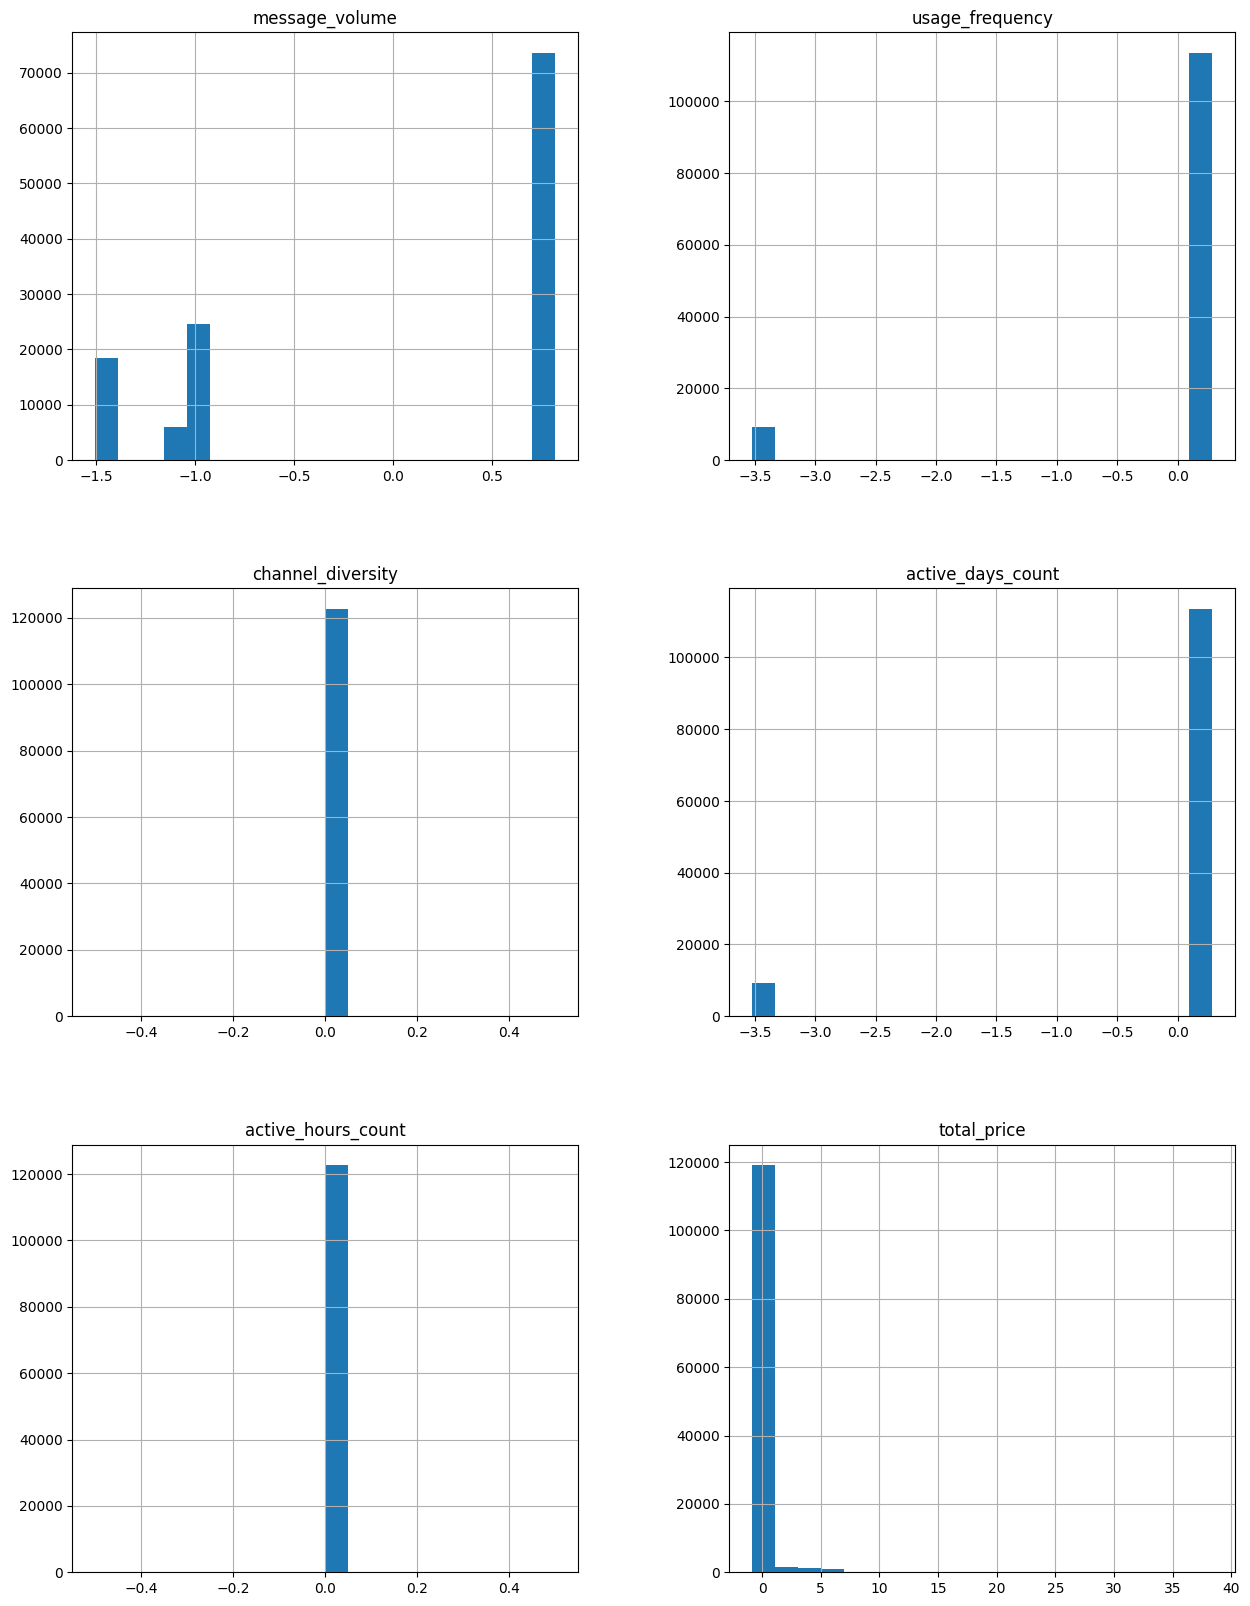

In [33]:
# histogram hasil scaling
df_scaled[num_features].hist(bins=20, figsize=(15, 20))

<Axes: >

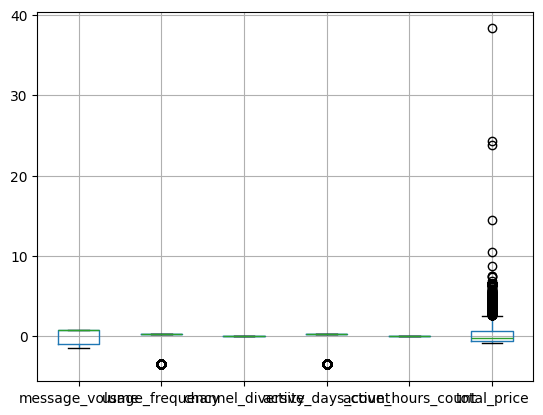

In [34]:
# boxplot hasil scaling
df_scaled[num_features].boxplot()

### Elbow & K Segmentation

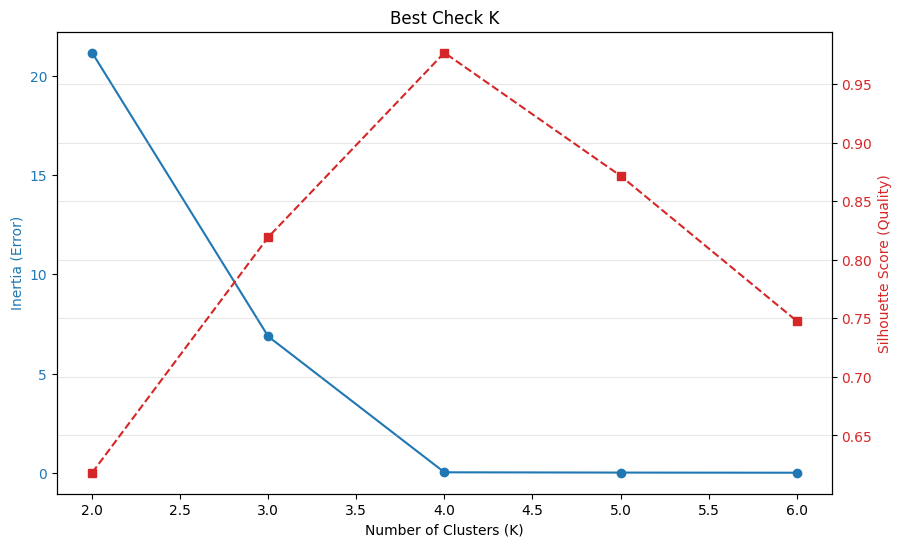

In [35]:
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. SIAPKAN DATA
# Asumsi df_OCA sudah di-load
user_rfm = df_OCA.groupby('user_id').agg({
    'transaction_id': 'count',           # Frequency
    'total_price': 'sum',                # Monetary
    'created_at': lambda x: x.dt.date.nunique() # Active Days
}).reset_index()

# Log Transform (Biar data gak bias ke angka gede doang)
user_rfm['log_freq'] = np.log1p(user_rfm['transaction_id'])
user_rfm['log_monetary'] = np.log1p(user_rfm['total_price'])
user_rfm['log_active'] = np.log1p(user_rfm['created_at'])

X = user_rfm[['log_freq', 'log_monetary', 'log_active']]

# Scaling (Penting biar Monetary gak mendominasi Frequency)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. CARI K TERBAIK (Range 2 sampai 6 aja cukup)
inertia = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# 3. VISUALISASI GABUNGAN
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Inertia (Elbow)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Error)', color='tab:blue')
ax1.plot(K_range, inertia, marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silhouette (Quality) - Sumbu Y sebelah kanan
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score (Quality)', color='tab:red')
ax2.plot(K_range, sil_scores, marker='s', linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Best Check K')
plt.grid(True, alpha=0.3)
plt.show()

## Which segment is most profitable ?

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [37]:
df_clean = df_OCA[df_OCA['is_charge']==True].copy()

# Today is last day created_at
max_date = df_clean['created_at'].max() + pd.Timedelta(days=1)

# Grouping to RFM
user_rfm = df_clean.groupby('user_id').agg({
    'transaction_id': 'count',           # Frequency (Real Paid Tx)
    'total_price': 'sum',                # Monetary (Real Revenue)
    'created_at': lambda x: x.dt.date.nunique() # Active Days
}).reset_index()

In [38]:
# Rename kolom RFM
user_rfm.rename(columns={
    'transaction_id': 'frequency',
    'total_price': 'monetary',
    'created_at': 'active_days'
}, inplace=True)

In [39]:
user_rfm['avg_daily_volume'] = user_rfm['frequency'] / user_rfm['active_days']

# Log transform
user_rfm['log_freq'] = np.log1p(user_rfm['frequency'])
user_rfm['log_monetary'] = np.log1p(user_rfm['monetary'])
user_rfm['log_active'] = np.log1p(user_rfm['active_days'])

X = user_rfm[['log_freq', 'log_monetary', 'log_active']]
scaler = StandardScaler()
user_rfm['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(scaler.fit_transform(X))

In [40]:
stats = user_rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False)
cluster_names = {
    stats.index[0]: 'Power User',
    stats.index[1]: 'Loyal User',
    stats.index[2]: 'Casual User'
}

user_rfm['segment_name'] = user_rfm['cluster'].map(cluster_names)

In [41]:
# hasil analisis
summary = user_rfm.groupby('segment_name').agg({
    'user_id': 'count',
    'avg_daily_volume': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'active_days': 'mean'
}).sort_values(by='monetary', ascending=False).reset_index()

summary['avg_daily_volume'] = summary['avg_daily_volume'].apply(lambda x: f"{x:.1f} tx/day")
summary['monetary'] = summary['monetary'].apply(lambda x: f"Rp {x:,.0f}")
summary['frequency'] = summary['frequency'].apply(lambda x: f"{x:,.0f}")

print("=== Segmen Paling Profitable (Data Bersih: is_charge=True) ===")
print(summary)

=== Segmen Paling Profitable (Data Bersih: is_charge=True) ===
  segment_name  user_id avg_daily_volume frequency      monetary  active_days
0   Power User        8     112.7 tx/day    10,252  Rp 2,753,209         91.0
1   Loyal User        8      13.4 tx/day     1,207    Rp 327,646         90.0
2  Casual User        4      13.4 tx/day     1,216    Rp 324,882         91.0


In [42]:

# Merge user_name into user_rfm DataFrame for display purposes
# First, ensure user_name column is not duplicated if the cell is run multiple times
if 'user_name' in user_rfm.columns:
    user_rfm = user_rfm.drop(columns=['user_name'])
user_rfm = user_rfm.merge(df_users[['user_id', 'user_name']], on='user_id', how='left')

# 5. FILTER KHUSUS POWER USER & URUTKAN PROFIT
top_users = user_rfm[user_rfm['segment_name'] == 'Power User'].sort_values(by='monetary', ascending=False)

# 6. TAMPILKAN TABEL RAPI
# Pilih kolom yang mau ditampilkan
display_table = top_users[['user_name', 'user_id', 'monetary', 'frequency', 'active_days']].copy()

# Format angka biar ada Rp dan Koma
display_table['monetary'] = display_table['monetary'].apply(lambda x: f"Rp {x:,.0f}")
display_table['frequency'] = display_table['frequency'].apply(lambda x: f"{x:,.0f}")

print("=== DAFTAR POWER USER PALING PROFITABLE (BY USERNAME) ===")
print(display_table.to_string(index=False))


=== DAFTAR POWER USER PALING PROFITABLE (BY USERNAME) ===
           user_name user_id     monetary frequency  active_days
      CV Wisata Indo  user_3 Rp 5,207,310    19,367           91
   PT Dana Nusantara  user_2 Rp 5,198,910    19,351           91
   CV Land Sejahtera  user_1 Rp 5,125,530    19,222           91
 PT Retail Sejahtera  user_7 Rp 1,327,690     4,853           91
  PT Karya Sejahtera  user_5 Rp 1,310,570     4,848           91
 PT Logistik Mandiri  user_6 Rp 1,294,970     4,725           91
PT Belajar Nusantara  user_8 Rp 1,284,620     4,799           91
PT Konektivitas Indo  user_4 Rp 1,276,070     4,854           91


### Visualisasi Most Profitable

In [43]:
# visualisasi most profitable by monetary
# Agregasi User
user_rfm = df_clean.groupby('user_id').agg({
    'transaction_id': 'count',
    'total_price': 'sum',
    'created_at': lambda x: x.dt.date.nunique()
}).reset_index()

user_rfm.rename(columns={'transaction_id': 'frequency', 'total_price': 'monetary', 'created_at': 'active_days'}, inplace=True)
user_rfm['avg_daily_volume'] = user_rfm['frequency'] / user_rfm['active_days']


In [44]:
# Cluster ulang
features = np.log1p(user_rfm[['frequency', 'monetary', 'active_days']])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
user_rfm['cluster'] = kmeans.fit_predict(X_scaled)

In [45]:
# Naming
rank = user_rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False).index
segment_map = {rank[0]: 'Power User', rank[1]: 'Loyal User', rank[2]: 'Casual User'}
user_rfm['segment_name'] = user_rfm['cluster'].map(segment_map)

# Merge balik ke data transaksi untuk analisis Channel & Status
df_merged = df_clean.merge(user_rfm[['user_id', 'segment_name']], on='user_id', how='left')


In [46]:
sns.set_style("whitegrid")
order = ['Power User', 'Loyal User', 'Casual User']
palette = {'Power User': '#36454F', 'Loyal User': '#36454F', 'Casual User': '#36454F'}

/tmp/ipython-input-3387278843.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_rfm, x='segment_name', y='avg_daily_volume', estimator=np.mean, errorbar=None, ax=ax1, order=order, palette=palette)
/tmp/ipython-input-3387278843.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_rfm, x='segment_name', y='monetary', estimator=np.mean, errorbar=None, ax=ax2, order=order, palette=palette)
/tmp/ipython-input-3387278843.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_rfm, x='segment_name', y='frequency', estim

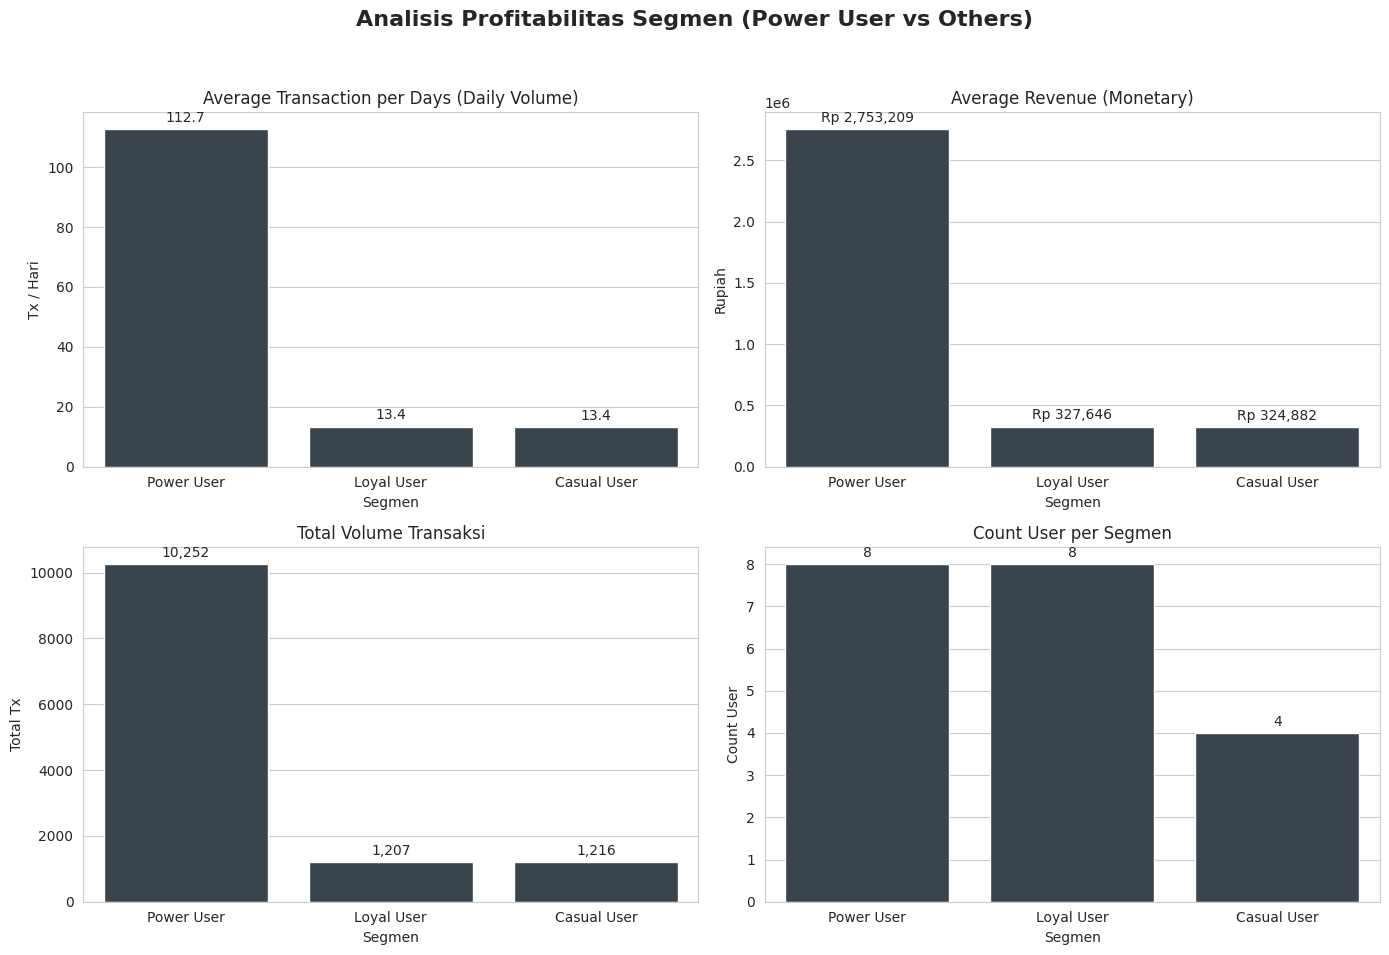

In [47]:
# A. KEY METRICS (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Profitabilitas Segmen (Power User vs Others)', fontsize=16, fontweight='bold')

# Avg Daily Volume
ax1 = axes[0,0]
sns.barplot(data=user_rfm, x='segment_name', y='avg_daily_volume', estimator=np.mean, errorbar=None, ax=ax1, order=order, palette=palette)
ax1.set_xlabel('Segmen')
ax1.set_ylabel('Tx / Hari')
ax1.set_title('Average Transaction per Days (Daily Volume)', fontsize=12)
# tampilkan label chart
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', padding=3)

# Monetary
ax2 = axes[0,1]
sns.barplot(data=user_rfm, x='segment_name', y='monetary', estimator=np.mean, errorbar=None, ax=ax2, order=order, palette=palette)
ax2.set_title('Average Revenue (Monetary)', fontsize=12)
ax2.set_ylabel('Rupiah')
ax2.set_xlabel('Segmen')
# Tambah label angka (Format Rupiah + Koma)
for container in ax2.containers:
    # Kita bikin format custom biar ada "Rp" dan koma pemisah ribuan
    labels = [f'Rp {val:,.0f}' for val in container.datavalues]
    ax2.bar_label(container, labels=labels, padding=3, fontsize=10)

# Frequency
ax3 = axes[1,0]
sns.barplot(data=user_rfm, x='segment_name', y='frequency', estimator=np.mean, errorbar=None, ax=ax3, order=order, palette=palette)
ax3.set_title('Total Volume Transaksi', fontsize=12)
ax3.set_ylabel('Total Tx')
ax3.set_xlabel('Segmen')
# Tambah label angka (Format Ribuan Koma)
for container in ax3.containers:
    labels = [f'{val:,.0f}' for val in container.datavalues]
    ax3.bar_label(container, labels=labels, padding=3)

# User Count
ax4 = axes[1,1]
sns.countplot(data=user_rfm, x='segment_name', ax=ax4, order=order, palette=palette)
ax4.set_title('Count User per Segmen', fontsize=12)
ax4.set_ylabel('Count User')
ax4.set_xlabel('Segmen')
# Tambah label angka (Polos)
for container in ax4.containers:
    ax4.bar_label(container, padding=3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<Figure size 1000x500 with 0 Axes>

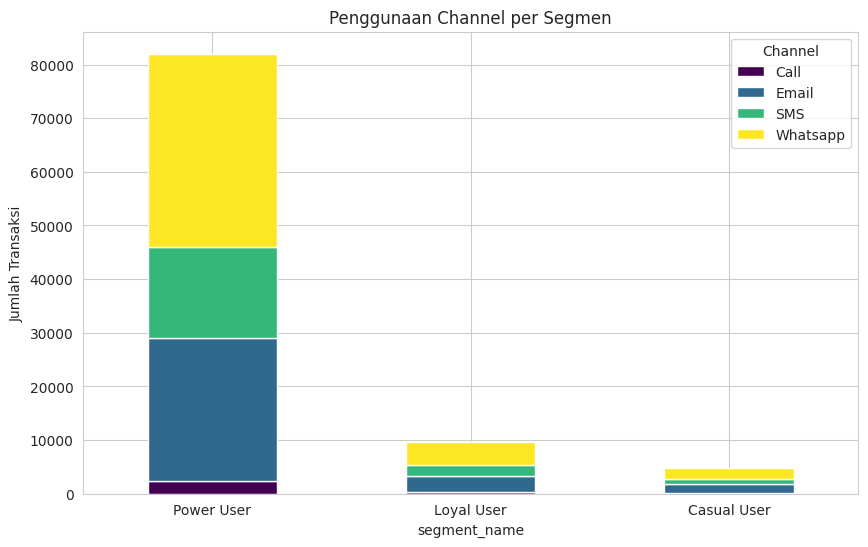

In [48]:
# B. CHANNEL USAGE with vertical bar
plt.figure(figsize=(10, 5))
channel_pivot = df_merged.groupby(['segment_name', 'channel']).size().unstack().fillna(0).loc[order]
channel_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='viridis')
plt.title('Penggunaan Channel per Segmen')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=0)
plt.legend(title='Channel')
plt.show()

<Figure size 1000x500 with 0 Axes>

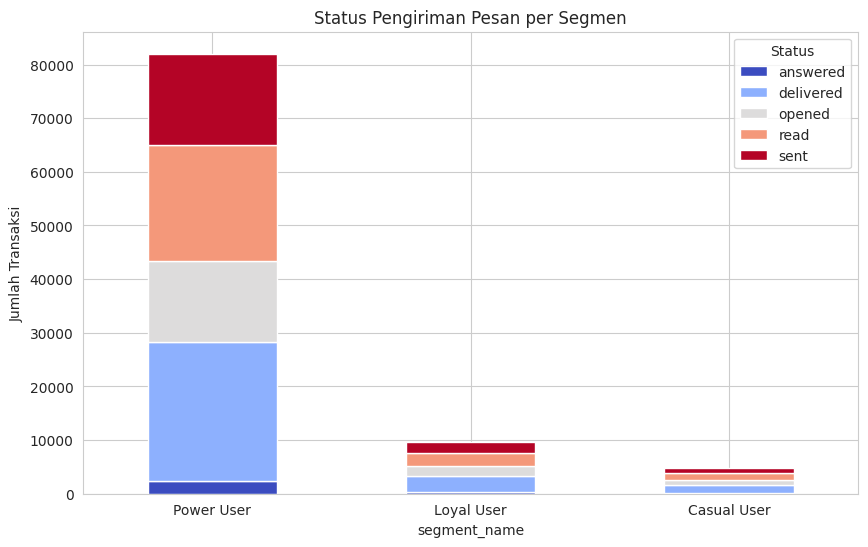

In [49]:
# C. STATUS PER CLUSTER
plt.figure(figsize=(10, 5))
status_pivot = df_merged.groupby(['segment_name', 'message_status']).size().unstack().fillna(0).loc[order]
status_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='coolwarm')
plt.title('Status Pengiriman Pesan per Segmen')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()

### Save to df_OCA

In [50]:
# Gabungkan segmen name, frequency, monetary dan avg daily volume ke df_oca
df_OCA['segment_name'] = df_OCA['user_id'].map(user_rfm.set_index('user_id')['segment_name'])
df_OCA['avg_daily_volume'] = df_OCA['user_id'].map(user_rfm.set_index('user_id')['avg_daily_volume'])
df_OCA['frequency'] = df_OCA['user_id'].map(user_rfm.set_index('user_id')['frequency'])
df_OCA['monetary'] = df_OCA['user_id'].map(user_rfm.set_index('user_id')['monetary'])
df_OCA.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122748 entries, 0 to 122747
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype                       
---  ------              --------------   -----                       
 0   transaction_id      122748 non-null  object                      
 1   user_id             122748 non-null  object                      
 2   message_type        50000 non-null   object                      
 3   total_price         122748 non-null  Int64                       
 4   message_status      122748 non-null  object                      
 5   is_charge           122748 non-null  boolean                     
 6   created_at          122748 non-null  datetime64[ns, Asia/Jakarta]
 7   received_timestamp  42387 non-null   datetime64[ns, Asia/Jakarta]
 8   channel             122748 non-null  object                      
 9   price               20000 non-null   Int64                       
 10  total_sms           20000 non-nu

## Which clients are most prone to churn ?

***Since the Recency data is all 0 (meaning all users are still actively transacting until the last day), we CANNOT use the classic method of “Old users who don't appear = Churn”.***

***Instead, we must look for “Early Warning Signals” such as Declining Usage Trends and High Failure Rates.***


**Metriks Trend score**

In [51]:
# Tren score
df_succ = df_OCA[df_OCA['is_charge'] == True].copy()
max_date = df_succ['created_at'].max()
cutoff_7d = max_date - pd.Timedelta(days=7)

In [52]:
# volume 7 hari terakhir
trend_df = df_succ.groupby('user_id').apply(
    lambda x: pd.Series({
        'vol_last_7d': x[x['created_at'] > cutoff_7d]['transaction_id'].count(),
        'vol_prev': x[x['created_at'] <= cutoff_7d]['transaction_id'].count(),
        'days_active_prev': x[x['created_at'] <= cutoff_7d]['created_at'].dt.date.nunique()
    })
).reset_index()

/tmp/ipython-input-3714626086.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_df = df_succ.groupby('user_id').apply(


In [53]:
# Hitung Rata-rata Harian Sebelumnya (biar fair)
trend_df['avg_daily_prev'] = trend_df['vol_prev'] / trend_df['days_active_prev'].replace(0, 1)

# Hitung Rata-rata Harian 7 Hari Terakhir (dibagi 7 hari)
trend_df['avg_daily_last_7d'] = trend_df['vol_last_7d'] / 7

# Hitung % Perubahan (Growth/Decline)
trend_df['usage_trend'] = (trend_df['avg_daily_last_7d'] - trend_df['avg_daily_prev']) / trend_df['avg_daily_prev']

**Metriks 2 Quality - Kepuasan**

In [54]:
quality_df = df_OCA.groupby('user_id').agg({
    'transaction_id': 'count',
    'message_status': lambda x: (x != 'delivered').sum() # Hitung yang GAK delivered
}).reset_index()

quality_df.rename(columns={'transaction_id': 'total_attempts', 'message_status': 'failed_count'}, inplace=True)
quality_df['failure_rate'] = quality_df['failed_count'] / quality_df['total_attempts']

**Combine**

In [55]:
churn_risk = trend_df.merge(quality_df, on='user_id')

# LABELING RISIKO
def determine_risk(row):
    # Kriteria 1: Error Rate tinggi (> 10%) -> HIGH RISK (Kecewa)
    if row['failure_rate'] > 0.10:
        return 'High Risk (Quality Issue)'

    # Kriteria 2: Usage Trend turun drastis (< -30%) -> HIGH RISK (Bosan/Pindah)
    elif row['usage_trend'] < -0.30:
        return 'High Risk (Usage Drop)'

    # Kriteria 3: Turun dikit -> MEDIUM
    elif row['usage_trend'] < -0.10:
        return 'Medium Risk'

    else:
        return 'Low Risk (Safe)'

churn_risk['churn_probability'] = churn_risk.apply(determine_risk, axis=1)

In [82]:
# Sort dari yang paling bahaya
report = churn_risk[['user_id', 'churn_probability', 'usage_trend', 'failure_rate', 'avg_daily_last_7d', 'avg_daily_prev']]
report = report.sort_values(by=['churn_probability', 'usage_trend'], ascending=[True, True])

# Formatting
report['usage_trend'] = report['usage_trend'].apply(lambda x: f"{x:.1%}")
report['failure_rate'] = report['failure_rate'].apply(lambda x: f"{x:.1%}")
report['avg_daily_last_7d'] = report['avg_daily_last_7d'].apply(lambda x: f"{x:.1f}")
report['avg_daily_prev'] = report['avg_daily_prev'].apply(lambda x: f"{x:.1f}")

print("=== LAPORAN PREDIKSI CHURN (RISK ANALYSIS) ===")
print(report.sort_values(by=['churn_probability', 'usage_trend'], ascending=[True, True]))

=== LAPORAN PREDIKSI CHURN (RISK ANALYSIS) ===
    user_id          churn_probability usage_trend failure_rate  \
1   user_10  High Risk (Quality Issue)      -10.1%        74.9%   
9   user_18  High Risk (Quality Issue)      -16.2%        75.2%   
7   user_16  High Risk (Quality Issue)      -16.6%        74.5%   
15   user_5  High Risk (Quality Issue)      -18.6%        75.5%   
13   user_3  High Risk (Quality Issue)      -20.9%        74.7%   
0    user_1  High Risk (Quality Issue)      -22.0%        75.4%   
17   user_7  High Risk (Quality Issue)      -22.9%        75.8%   
14   user_4  High Risk (Quality Issue)      -23.8%        75.3%   
12  user_20  High Risk (Quality Issue)      -24.5%        75.0%   
4   user_13  High Risk (Quality Issue)      -26.2%        74.5%   
11   user_2  High Risk (Quality Issue)      -28.2%        74.9%   
8   user_17  High Risk (Quality Issue)      -30.2%        73.4%   
18   user_8  High Risk (Quality Issue)      -30.4%        75.2%   
16   user_6  Hi

In [57]:
report.describe()

,user_id,churn_probability,usage_trend,failure_rate,avg_daily_last_7d,avg_daily_prev
count,20,20,20,20,20,20
unique,20,1,20,15,20,14
top,user_11,High Risk (Quality Issue),-43.8%,74.9%,7.9,13.8
freq,1,20,1,3,1,3


### Visualisasi most prone to churn

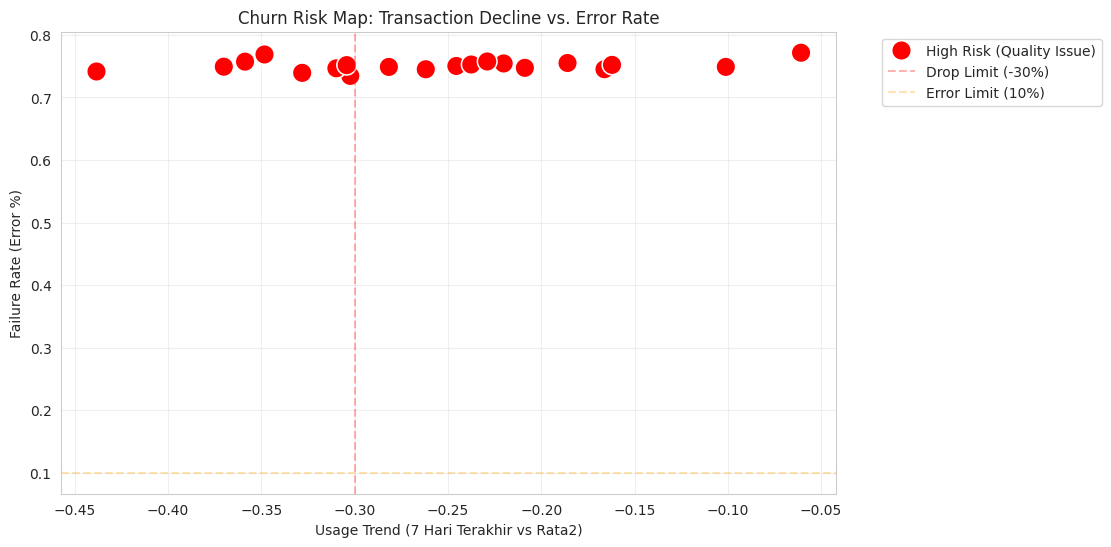

In [58]:
plt.figure(figsize=(10, 6))
risk_colors ={
    'High Risk (Quality Issue)': 'red',
    'High Risk (Usage Drop)': 'orange',
    'Medium Risk': 'yellow',
    'Low Risk (Safe)': 'green'
}

sns.scatterplot(
    data=churn_risk,
    x='usage_trend',
    y='failure_rate',
    hue='churn_probability',
    palette=risk_colors,
    s=200 # ukuran dot
)

plt.axvline(x=-0.3, color='red', linestyle='--', alpha=0.3, label='Drop Limit (-30%)')
plt.axhline(y=0.1, color='orange', linestyle='--', alpha=0.3, label='Error Limit (10%)')

plt.title('Churn Risk Map: Transaction Decline vs. Error Rate')
plt.xlabel('Usage Trend (7 Hari Terakhir vs Rata2)')
plt.ylabel('Failure Rate (Error %)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


The table below shows that ALL 20 users fall into the High Risk (Quality Issue) category.

Your users' average failure rate is between 74% and 77%. This means that out of every 10 messages they send, 7 fail to deliver (Undelivered/Failed). Only 3 are successful.

In [59]:
# 2. HITUNG METRIK PER USER
def calculate_risk_metrics(x):
    # Set Cutoff 7 Hari Terakhir
    max_date = df_clean['created_at'].max()
    cutoff = max_date - pd.Timedelta(days=7)

    # Bagi Data: Recent vs Past
    recent = x[x['created_at'] > cutoff]
    past = x[x['created_at'] <= cutoff]

    # Hitung Volume Harian (Avg)
    # Dibagi 7 hari fix untuk recent, biar kelihatan intensitas mingguan
    vol_recent = len(recent) / 7
    # Dibagi total hari aktif di masa lalu (atau 1 jika 0)
    days_past = past['created_at'].dt.date.nunique()
    vol_past = len(past) / (days_past if days_past > 0 else 1)

    # Hitung Trend (%)
    if vol_past == 0:
        trend = 0 # Anggap stabil kalau user baru
    else:
        trend = (vol_recent - vol_past) / vol_past

    return pd.Series({
        'revenue': x['total_price'].sum(),
        'volume_total': len(x),
        'usage_trend': trend
    })

risk_df = df_clean.groupby('user_id').apply(calculate_risk_metrics).reset_index()

# 3. TAMBAHKAN SUCCESS RATE (Sebagai konteks aja, bukan penentu utama)
# Hitung dari data mentah (df) karena butuh status 'delivered' vs 'failed'
success_rate = df_OCA.groupby('user_id')['message_status'].apply(lambda x: (x == 'delivered').mean()).reset_index(name='success_rate')
risk_df = risk_df.merge(success_rate, on='user_id')

# 4. LOGIKA KATEGORI RISIKO (MATRIX BARU)
# Kita tentukan threshold "Sultan" (High Value)
# Misal: Top 30% revenue tertinggi dianggap "Big Fish"
threshold_revenue = risk_df['revenue'].quantile(0.7)

def determine_risk(row):
    # Parameter Utama: Trend
    # Kalau turun lebih dari 20%, kita anggap Warning
    is_declining = row['usage_trend'] < -0.20

    # Parameter Kedua: Revenue
    is_high_value = row['revenue'] >= threshold_revenue

    if is_declining and is_high_value:
        return 'CRITICAL (Big Fish Leaving)'  # Prioritas 1
    elif is_declining and not is_high_value:
        return 'High Risk (Standard)'         # Prioritas 2
    elif not is_declining and is_high_value:
        return 'Safe (Star User)'             # Aset Dijaga
    else:
        return 'Safe (Standard)'              # Aman

risk_df['risk_category'] = risk_df.apply(determine_risk, axis=1)

# 5. TAMPILKAN HASIL
# Urutkan berdasarkan Kategori Risiko lalu Trend terburuk
risk_order = ['CRITICAL (Big Fish Leaving)', 'High Risk (Standard)', 'Safe (Star User)', 'Safe (Standard)']
risk_df['risk_category'] = pd.Categorical(risk_df['risk_category'], categories=risk_order, ordered=True)
final_report = risk_df.sort_values(by=['risk_category', 'usage_trend'])

# Rapikan Format Angka
final_report['revenue'] = final_report['revenue'].apply(lambda x: f"Rp {x:,.0f}")
final_report['usage_trend'] = final_report['usage_trend'].apply(lambda x: f"{x:.1%}")
final_report['success_rate'] = final_report['success_rate'].apply(lambda x: f"{x:.1%}")

print("=== ANALISIS RISIKO CHURN (FOKUS TREND & REVENUE) ===")
print(final_report[['user_id', 'risk_category', 'usage_trend', 'revenue', 'success_rate']])

=== ANALISIS RISIKO CHURN (FOKUS TREND & REVENUE) ===
    user_id                risk_category usage_trend       revenue  \
16   user_6  CRITICAL (Big Fish Leaving)      -31.0%  Rp 1,294,970   
11   user_2  CRITICAL (Big Fish Leaving)      -28.2%  Rp 5,198,910   
17   user_7  CRITICAL (Big Fish Leaving)      -22.9%  Rp 1,327,690   
0    user_1  CRITICAL (Big Fish Leaving)      -22.0%  Rp 5,125,530   
13   user_3  CRITICAL (Big Fish Leaving)      -20.9%  Rp 5,207,310   
2   user_11         High Risk (Standard)      -43.8%    Rp 340,730   
19   user_9         High Risk (Standard)      -37.0%    Rp 317,510   
3   user_12         High Risk (Standard)      -35.9%    Rp 300,770   
10  user_19         High Risk (Standard)      -34.8%    Rp 336,210   
5   user_14         High Risk (Standard)      -32.8%    Rp 305,880   
18   user_8         High Risk (Standard)      -30.4%  Rp 1,284,620   
8   user_17         High Risk (Standard)      -30.2%    Rp 315,770   
4   user_13         High Risk (Stand

/tmp/ipython-input-219399737.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_df = df_clean.groupby('user_id').apply(calculate_risk_metrics).reset_index()


**visualisasi**

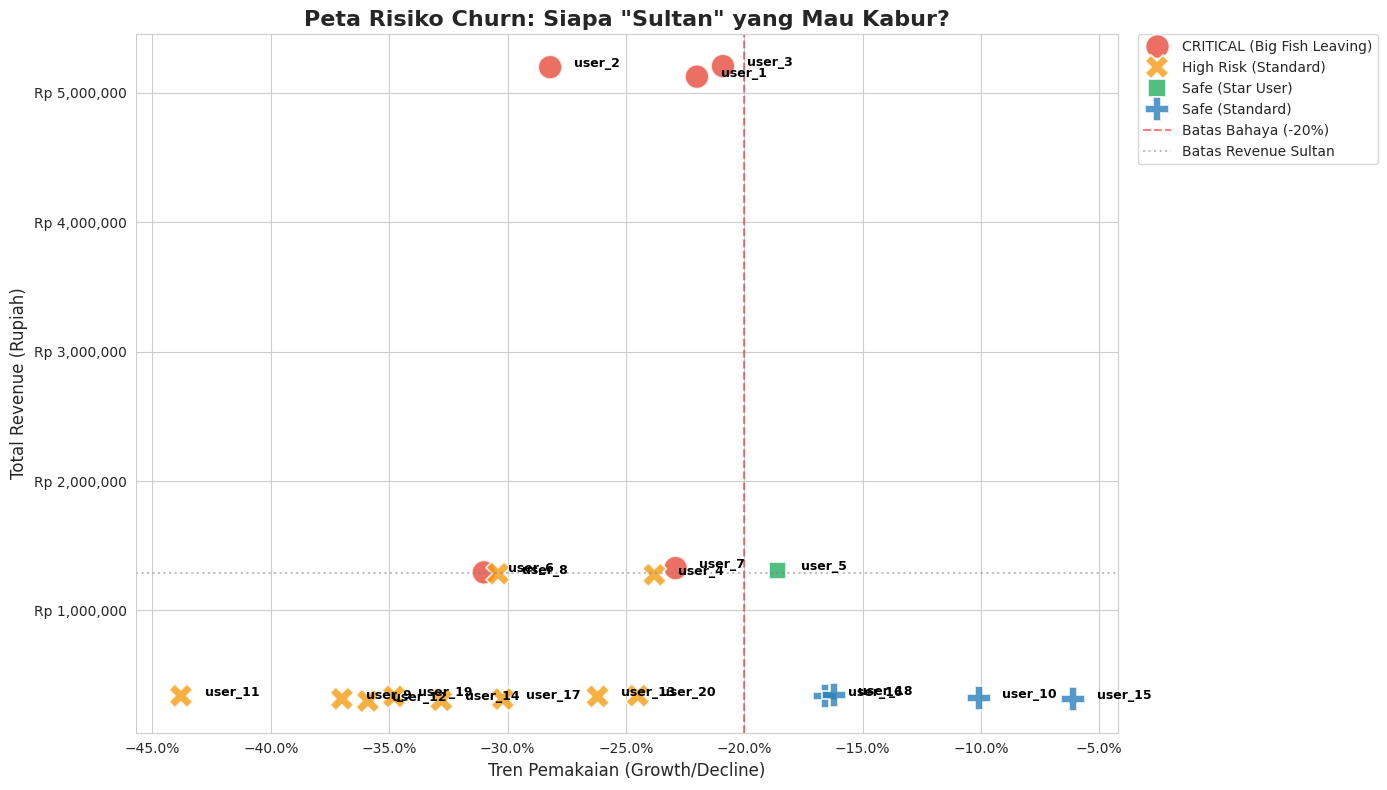

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. SETUP KANVAS
plt.figure(figsize=(14, 8)) # Ukuran gambar biar lega
sns.set_style("whitegrid") # Pake grid biar gampang baca koordinat

# Create numeric versions of usage_trend and revenue for plotting
# This ensures the plotting functions can perform arithmetic operations.
final_report['numeric_usage_trend'] = final_report['usage_trend'].str.replace('%', '').astype(float) / 100
final_report['numeric_revenue'] = final_report['revenue'].str.replace('Rp ', '').str.replace(',', '').astype(float)

# 2. BIKIN SCATTER PLOT
# Kita petakan: Sumbu X = Trend, Sumbu Y = Revenue
plot = sns.scatterplot(
    data=final_report,
    x='numeric_usage_trend', # Use the numeric version for plotting
    y='numeric_revenue',    # Use the numeric version for plotting
    hue='risk_category', # Warna berdasarkan status risiko
    style='risk_category', # Bentuk titik beda-beda (bulat/kotak) biar makin jelas
    palette={
        'CRITICAL (Big Fish Leaving)': '#e74c3c', # Merah Bahaya
        'High Risk (Standard)': '#f39c12',        # Orange
        'Safe (Star User)': '#27ae60',            # Hijau Tua
        'Safe (Standard)': '#2980b9'              # Biru Santuy
    },
    s=300, # Ukuran titik (makin gede makin enak dilihat)
    alpha=0.8 # Transparansi dikit biar kalau numpuk kelihatan
)

# 3. KASIH GARIS BATAS (THRESHOLD)
# Garis Vertikal di -20% (Batas Churn)
plt.axvline(x=-0.2, color='red', linestyle='--', alpha=0.5, label='Batas Bahaya (-20%)')
# Garis Horizontal di Revenue Threshold (Batas Sultan)
plt.axhline(y=threshold_revenue, color='grey', linestyle=':', alpha=0.5, label='Batas Revenue Sultan')

# 4. TAMPILIN NAMA USER DI SAMPING TITIK
# Ini looping buat nempelin teks "user_1", "user_2" di sebelah titiknya
for i in range(final_report.shape[0]):
    plt.text(
        x=final_report.numeric_usage_trend.iloc[i] + 0.01, # Use numeric column
        y=final_report.numeric_revenue.iloc[i],           # Use numeric column
        s=final_report.user_id.iloc[i],
        fontdict=dict(color='black', size=9, weight='bold')
    )

# 5. PERCANTIK LABEL & JUDUL
plt.title('Peta Risiko Churn: Siapa "Sultan" yang Mau Kabur?', fontsize=16, fontweight='bold')
plt.xlabel('Tren Pemakaian (Growth/Decline)', fontsize=12)
plt.ylabel('Total Revenue (Rupiah)', fontsize=12)

# Format Sumbu X jadi Persen (biar muncul -20%, bukan -0.2)
plot.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

# Format Sumbu Y jadi Rupiah (biar gak muncul angka ilmiah 1e6)
plot.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x:,.0f}'))

# Geser Legend biar gak nutupin gambar
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

In [87]:
# With segmentation
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Re-create user_rfm with segmentation to ensure it's up-to-date
# 1. Aggregate transactional data to get RFM features
user_rfm = df_clean.groupby('user_id').agg({
    'transaction_id': 'count',           # Frequency
    'total_price': 'sum',                # Monetary
    'created_at': lambda x: x.dt.date.nunique() # Active Days
}).reset_index()

user_rfm.rename(columns={
    'transaction_id': 'frequency',
    'total_price': 'monetary',
    'created_at': 'active_days'
}, inplace=True)

# 2. Add average daily volume (if needed for analysis, though not used in clustering)
user_rfm['avg_daily_volume'] = user_rfm['frequency'] / user_rfm['active_days']

# 3. Log Transform for skewed data and Scale features
user_rfm['log_freq'] = np.log1p(user_rfm['frequency'])
user_rfm['log_monetary'] = np.log1p(user_rfm['monetary'])
user_rfm['log_active'] = np.log1p(user_rfm['active_days'])

X = user_rfm[['log_freq', 'log_monetary', 'log_active']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform KMeans clustering (assuming 3 clusters from previous analysis for profitability)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
user_rfm['cluster'] = kmeans.fit_predict(X_scaled)

# 5. Assign segment names based on cluster (re-using the logic from cell DuuIGsZ_RRZh)
# First, determine the ranking of clusters by monetary value to assign names
stats = user_rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False)
rank = stats.index
segment_map = {
    rank[0]: 'Power User',
    rank[1]: 'Loyal User',
    rank[2]: 'Casual User'
}
user_rfm['segment_name'] = user_rfm['cluster'].map(segment_map)

# Now, continue with the original logic of the cell
def calculate_risk_metrics(x):
    max_date = df_clean['created_at'].max()
    cutoff = max_date - pd.Timedelta(days=7)

    recent = x[x['created_at'] > cutoff]
    past = x[x['created_at'] <= cutoff]

    vol_recent = len(recent) / 7
    days_past = past['created_at'].dt.date.nunique()
    vol_past = len(past) / (days_past if days_past > 0 else 1)

    if vol_past == 0:
        trend = 0
    else:
        trend = (vol_recent - vol_past) / vol_past

    return pd.Series({
        'revenue': x['total_price'].sum(), # Masih dihitung buat display
        'volume_total': len(x),
        'usage_trend': trend
    })

risk_df = df_clean.groupby('user_id').apply(calculate_risk_metrics).reset_index()

# 2. GABUNGKAN DENGAN SEGMENTASI (PENTING!)
# Kita ambil info segmen (Power/Loyal/Casual) dari hasil clustering sebelumnya
# Asumsi: df 'user_rfm' dari tahap clustering masih ada
risk_df = risk_df.merge(user_rfm[['user_id', 'segment_name']], on='user_id', how='left')

# 3. TAMBAHKAN SUCCESS RATE
success_rate = df_OCA.groupby('user_id')['message_status'].apply(lambda x: (x == 'delivered').mean()).reset_index(name='success_rate')
risk_df = risk_df.merge(success_rate, on='user_id')

# 4. LOGIKA KATEGORI RISIKO (SESUAI 3 SEGMEN)
def determine_risk(row):
    # Cek apakah tren turun parah (> 20%)
    is_declining = row['usage_trend'] < -0.20
    segment = row['segment_name']

    if is_declining:
        # Kalau tren turun, cek dia segmen apa
        if segment == 'Power User':
            return 'CRITICAL (Power User Churn)'  # Paling Bahaya
        elif segment == 'Loyal User':
            return 'High Risk (Loyal User)'       # Bahaya Menengah
        else:
            return 'Moderate Risk (Casual User)'  # Bahaya Biasa
    else:
        # Kalau tren aman/naik
        return f'Safe ({segment})'

risk_df['risk_category'] = risk_df.apply(determine_risk, axis=1)

# 5. TAMPILKAN HASIL
# Urutkan custom biar yang Critical paling atas
risk_order = [
    'CRITICAL (Power User Churn)',
    'High Risk (Loyal User)',
    'Moderate Risk (Casual User)',
    'Safe (Power User)',
    'Safe (Loyal User)',
    'Safe (Casual User)'
]

risk_df['risk_category'] = pd.Categorical(risk_df['risk_category'], categories=risk_order, ordered=True)
final_report = risk_df.sort_values(by=['risk_category', 'usage_trend'])

# Rapikan Format Angka
final_report_display = final_report.copy()
final_report_display['revenue'] = final_report_display['revenue'].apply(lambda x: f"Rp {x:,.0f}")
final_report_display['usage_trend'] = final_report_display['usage_trend'].apply(lambda x: f"{x:.1%}")
final_report_display['success_rate'] = final_report_display['success_rate'].apply(lambda x: f"{x:.1%}")

print("=== ANALISIS RISIKO CHURN BERDASARKAN 3 SEGMEN ===")
print(final_report_display[['user_id', 'segment_name', 'risk_category', 'usage_trend', 'revenue', 'success_rate']]
      .sort_values('success_rate', ascending=True).to_string(index=False))

=== ANALISIS RISIKO CHURN BERDASARKAN 3 SEGMEN ===
user_id segment_name               risk_category usage_trend      revenue success_rate
user_15   Loyal User           Safe (Loyal User)       -6.1%   Rp 318,840        22.8%
user_19   Loyal User      High Risk (Loyal User)      -34.8%   Rp 336,210        23.1%
 user_7   Power User CRITICAL (Power User Churn)      -22.9% Rp 1,327,690        24.2%
user_12  Casual User Moderate Risk (Casual User)      -35.9%   Rp 300,770        24.3%
 user_5   Power User           Safe (Power User)      -18.6% Rp 1,310,570        24.5%
 user_1   Power User CRITICAL (Power User Churn)      -22.0% Rp 5,125,530        24.6%
 user_4   Power User CRITICAL (Power User Churn)      -23.8% Rp 1,276,070        24.7%
 user_8   Power User CRITICAL (Power User Churn)      -30.4% Rp 1,284,620        24.8%
user_18   Loyal User           Safe (Loyal User)      -16.2%   Rp 344,080        24.8%
user_20  Casual User Moderate Risk (Casual User)      -24.5%   Rp 342,240      

/tmp/ipython-input-272221597.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_df = df_clean.groupby('user_id').apply(calculate_risk_metrics).reset_index()


In [62]:
# sort hanya segment name "power user"
print("=== ANALISIS RISIKO CHURN BERDASARKAN 3 SEGMEN ===")
print(final_report_display[['user_id', 'segment_name', 'risk_category', 'usage_trend', 'revenue', 'success_rate']]
      .sort_values(by=['risk_category','user_id'], ascending=True).to_string(index=False))


=== ANALISIS RISIKO CHURN BERDASARKAN 3 SEGMEN ===
user_id segment_name               risk_category usage_trend      revenue success_rate
 user_1   Power User CRITICAL (Power User Churn)      -22.0% Rp 5,125,530        24.6%
 user_2   Power User CRITICAL (Power User Churn)      -28.2% Rp 5,198,910        25.1%
 user_3   Power User CRITICAL (Power User Churn)      -20.9% Rp 5,207,310        25.3%
 user_4   Power User CRITICAL (Power User Churn)      -23.8% Rp 1,276,070        24.7%
 user_6   Power User CRITICAL (Power User Churn)      -31.0% Rp 1,294,970        25.3%
 user_7   Power User CRITICAL (Power User Churn)      -22.9% Rp 1,327,690        24.2%
 user_8   Power User CRITICAL (Power User Churn)      -30.4% Rp 1,284,620        24.8%
user_11   Loyal User      High Risk (Loyal User)      -43.8%   Rp 340,730        25.8%
user_13   Loyal User      High Risk (Loyal User)      -26.2%   Rp 335,960        25.5%
user_14   Loyal User      High Risk (Loyal User)      -32.8%   Rp 305,880      

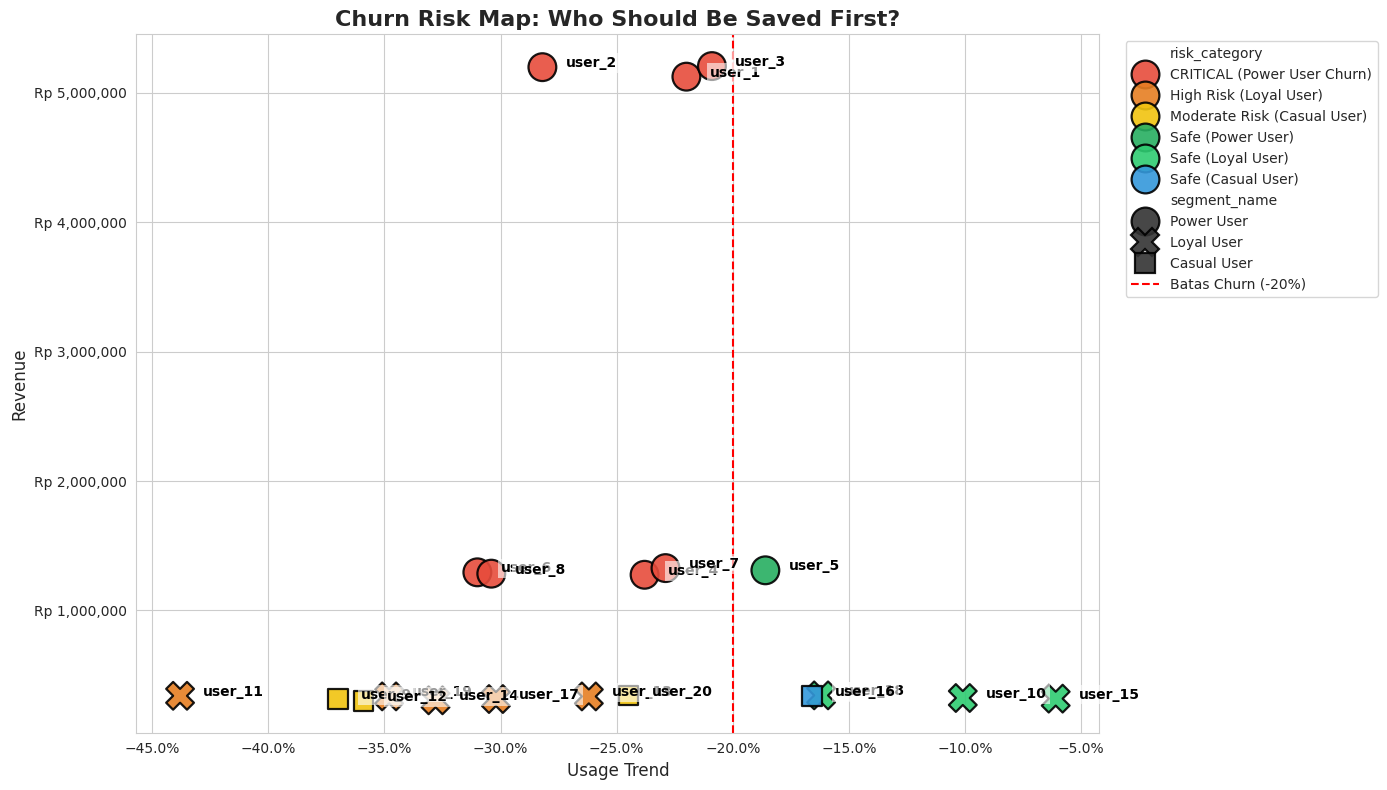

In [88]:
import matplotlib.ticker as ticker

# Pastikan 'final_df' sudah ter-create dari step sebelumnya
# (Kode merging segment + trend tadi)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Warna Warni Warning
colors = {
    'CRITICAL (Power User Churn)': '#e74c3c',  # Merah (BAHAYA!)
    'High Risk (Loyal User)': '#e67e22',       # Orange
    'Moderate Risk (Casual User)': '#f1c40f',  # Kuning - Corrected key
    'Safe (Power User)': '#27ae60',            # Hijau Tua
    'Safe (Loyal User)': '#2ecc71',            # Hijau Muda
    'Safe (Casual User)': '#3498db'            # Biru
}

# Add numeric versions of the formatted columns to final_report_display for plotting
final_report_display['numeric_usage_trend'] = final_report_display['usage_trend'].str.replace('%', '').astype(float) / 100
final_report_display['numeric_revenue'] = final_report_display['revenue'].str.replace('Rp ', '').str.replace(',', '').astype(float)


# Plotting
plot = sns.scatterplot(
    data=final_report_display,
    x='numeric_usage_trend', # Changed from 'usage_trend'
    y='numeric_revenue',     # Changed from 'monetary'
    hue='risk_category',
    style='segment_name', # Bentuk titik beda tiap segmen (Bulat/Kotak/Silang)
    palette=colors,
    s=400, # Ukuran titik gede biar mantap
    alpha=0.9,
    edgecolor='black'
)

# Garis Batas Suci (-20%)
plt.axvline(x=-0.2, color='red', linestyle='--', label='Batas Churn (-20%)')

# Tempelin Nama User
for i in range(final_report_display.shape[0]):
    plt.text(
        x=final_report_display.numeric_usage_trend.iloc[i] + 0.01, # Use numeric column
        y=final_report_display.numeric_revenue.iloc[i],          # Use numeric column
        s=final_report_display.user_id.iloc[i],
        fontdict=dict(color='black', size=10, weight='bold'),
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
    )

# Judul & Label
plt.title('Churn Risk Map: Who Should Be Saved First?', fontsize=16, fontweight='bold')
plt.xlabel('Usage Trend', fontsize=12)
plt.ylabel('Revenue', fontsize=12)

# Format Angka (Rp & %)
plot.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
plot.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x:,.0f}'))

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### save to OCA

In [64]:
# gabungkan data trend dan quality ke dalam df_OCA
df_OCA['usage_trend'] = df_OCA['user_id'].map(churn_risk.set_index('user_id')['usage_trend'])
df_OCA['failure_rate'] = df_OCA['user_id'].map(churn_risk.set_index('user_id')['failure_rate'])
df_OCA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122748 entries, 0 to 122747
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype                       
---  ------              --------------   -----                       
 0   transaction_id      122748 non-null  object                      
 1   user_id             122748 non-null  object                      
 2   message_type        50000 non-null   object                      
 3   total_price         122748 non-null  Int64                       
 4   message_status      122748 non-null  object                      
 5   is_charge           122748 non-null  boolean                     
 6   created_at          122748 non-null  datetime64[ns, Asia/Jakarta]
 7   received_timestamp  42387 non-null   datetime64[ns, Asia/Jakarta]
 8   channel             122748 non-null  object                      
 9   price               20000 non-null   Int64                       
 10  total_sms           20000 non-nu

## Do high-volume users show unique hourly patterns ?

In [65]:
df_merged['hour'] = df_merged['created_at'].dt.hour

In [66]:
# HITUNG AGREGASI
# jumlah transaksi per segmen per jam
hourly_data = df_merged.groupby(['segment_name', 'hour']).size().reset_index(name='count')

# total transaksi per segmen
total_per_segment = df_merged.groupby('segment_name').size().reset_index(name='total')
hourly_data = hourly_data.merge(total_per_segment, on='segment_name')


In [67]:
# Normalisasi
hourly_data['percentage'] = (hourly_data['count'] / hourly_data['total']) * 100

Text(0.5, 1.0, 'Percentage of Hourly Transactions per segment')

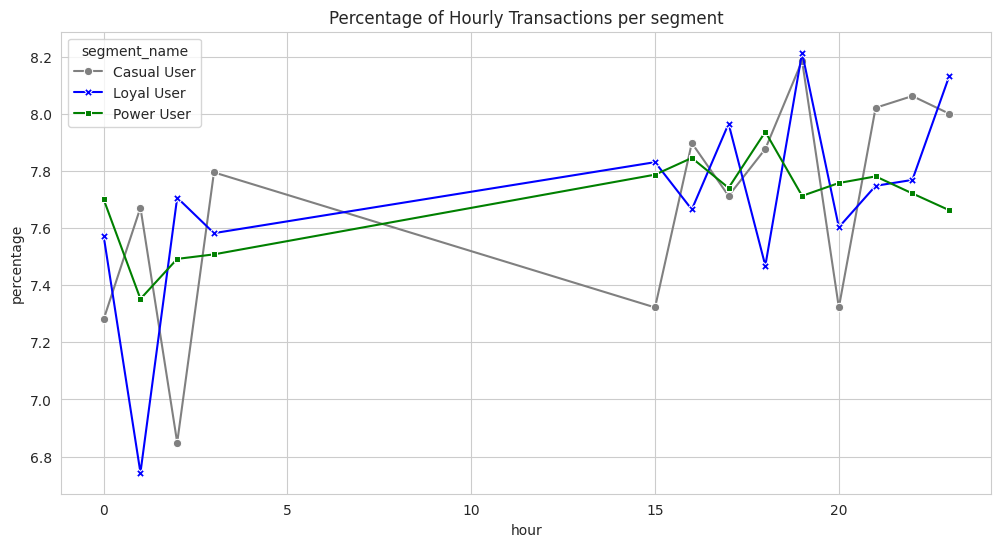

In [68]:
# visualisasi
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly_data,
    x='hour',
    y='percentage',
    hue='segment_name',
    style = 'segment_name',
    markers=True,
    dashes=False,
    palette={'Power User': 'green', 'Loyal User': 'blue', 'Casual User': 'grey'}
)
plt.title('Percentage of Hourly Transactions per segment')


Text(0.5, 1.0, 'Average Transaction per segment')

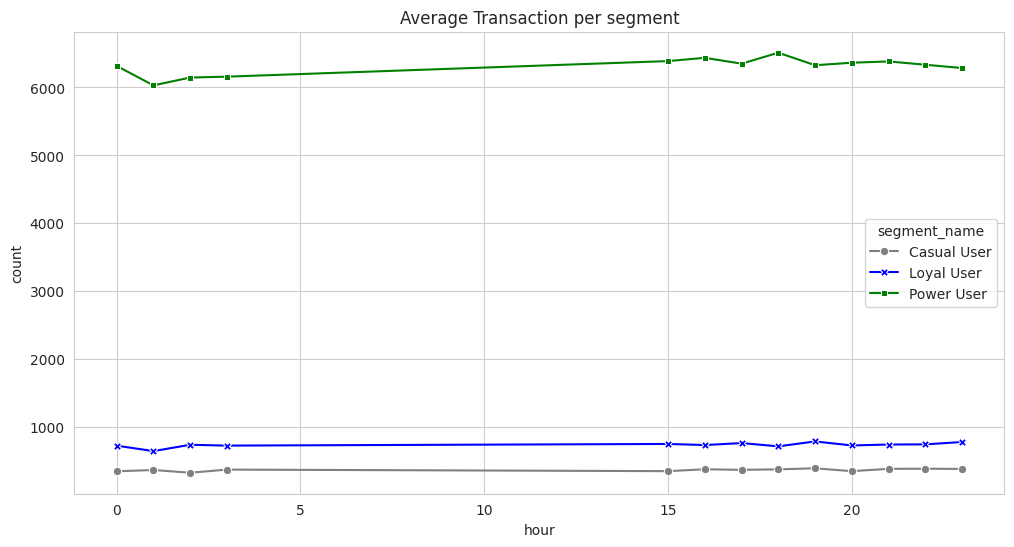

In [69]:
# visualisasi hourly intensity (Average Transaction per User)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly_data,
    x='hour',
    y='count',
    hue='segment_name',
    style = 'segment_name',
    markers=True,
    dashes=False,
    palette={'Power User': 'green', 'Loyal User': 'blue', 'Casual User': 'grey'}
)
plt.title('Average Transaction per segment')

/tmp/ipython-input-1732727931.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Segmen', loc='upper left')


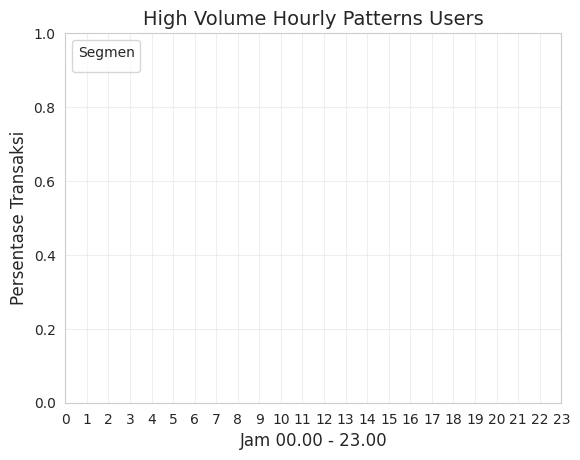

In [70]:
plt.title('High Volume Hourly Patterns Users', fontsize=14)
plt.xlabel('Jam 00.00 - 23.00', fontsize=12)
plt.ylabel('Persentase Transaksi', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='Segmen', loc='upper left')
plt.show()

## Do mono-channel users have upsell potential ?

channel
Whatsapp    43.908427
Email       32.553996
SMS         20.649505
Call         2.888072
Name: proportion, dtype: float64


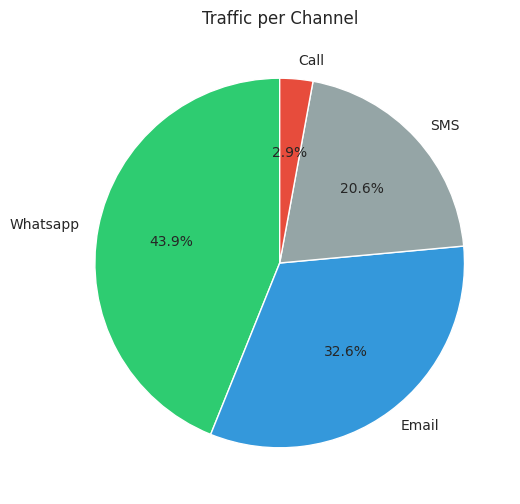

In [71]:
# Traffic per Channel
channel_share = df_clean['channel'].value_counts(normalize=True) * 100
print(channel_share)

# visualisasi
plt.figure(figsize=(6, 6))
plt.pie(channel_share, labels=channel_share.index, autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#3498db', '#95a5a6', '#e74c3c'])
plt.title('Traffic per Channel')
plt.show()

In [72]:
# Compared user in field of business
# Hitung Persen
# combine Bisnis - User - Channel
usage = df_clean.groupby(['field_of_business', 'user_id', 'channel']).size().reset_index(name='count')

# Total per user
user_total = usage.groupby('user_id')['count'].transform('sum')
usage['percentage'] = (usage['count'] / user_total) * 100

In [73]:
# tampilkan presentasi per industri
usage['field_of_business'].value_counts(normalize=True) * 100


,proportion
field_of_business,
Education,20.0
Hospitality,20.0
Retail,15.0
Real Estate,10.0
Finance,10.0
Travel,10.0
Logistics,5.0
Telecommunications,5.0
eCommerce,5.0


In [74]:
tabel_persentase = usage.pivot_table(
    index=['field_of_business', 'user_id'],
    columns='channel',
    values='percentage',
    fill_value=0  # Isi 0 jika user tidak pernah pakai channel tsb
)

print("=== TABEL PERSENTASE CHANNEL PER USER & INDUSTRI ===")
pd.options.display.float_format = '{:.1f}%'.format
print(tabel_persentase)

=== TABEL PERSENTASE CHANNEL PER USER & INDUSTRI ===
channel                     Call  Email   SMS  Whatsapp
field_of_business  user_id                             
Education          user_15  2.9%  32.1% 21.4%     43.6%
                   user_17  3.0%  30.8% 19.4%     46.8%
                   user_5   3.1%  32.8% 21.0%     43.1%
                   user_8   2.5%  31.9% 20.9%     44.7%
Finance            user_13  3.1%  31.5% 21.3%     44.0%
                   user_2   2.8%  33.0% 20.5%     43.6%
Hospitality        user_11  3.2%  31.6% 21.1%     44.1%
                   user_14  2.7%  34.1% 18.6%     44.6%
                   user_20  2.9%  33.0% 21.0%     43.1%
                   user_9   2.5%  35.1% 20.2%     42.2%
Logistics          user_6   3.1%  31.9% 20.3%     44.7%
Real Estate        user_1   3.0%  32.3% 20.5%     44.2%
                   user_16  2.1%  33.8% 20.8%     43.2%
Retail             user_10  2.6%  32.2% 21.7%     43.4%
                   user_12  3.3%  33.9% 20.1%     4

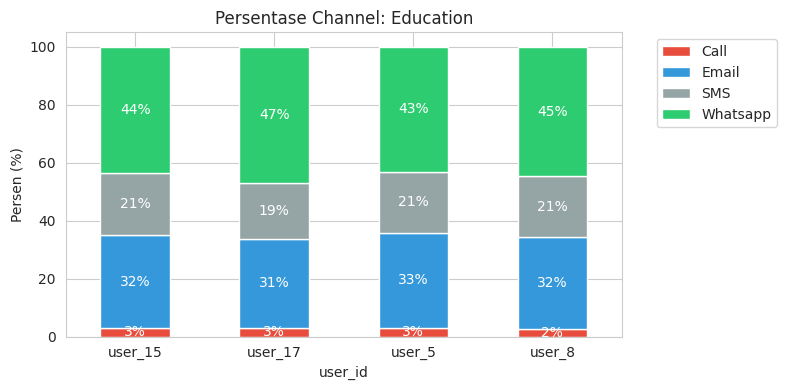

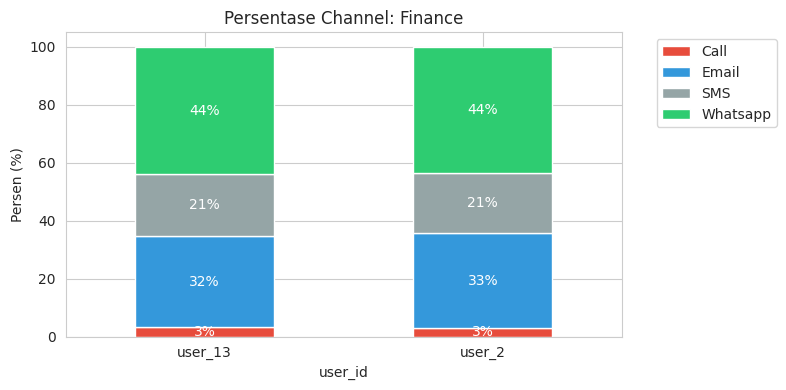

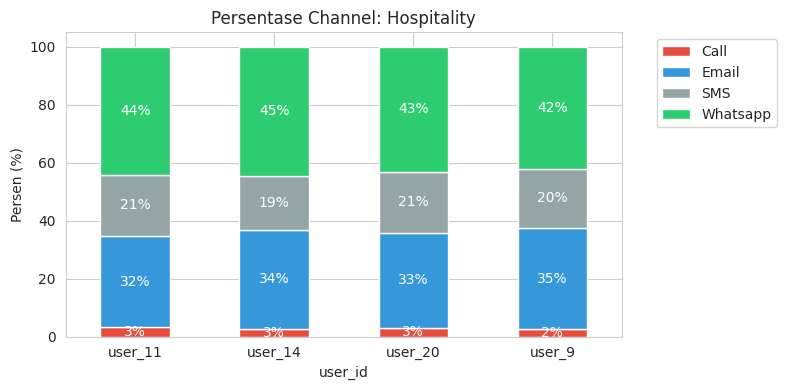

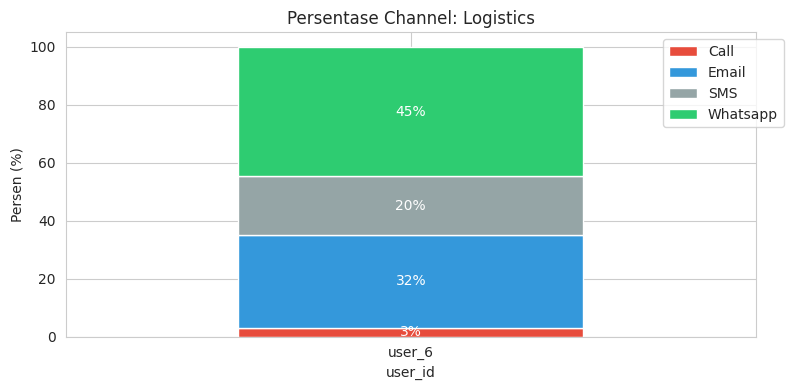

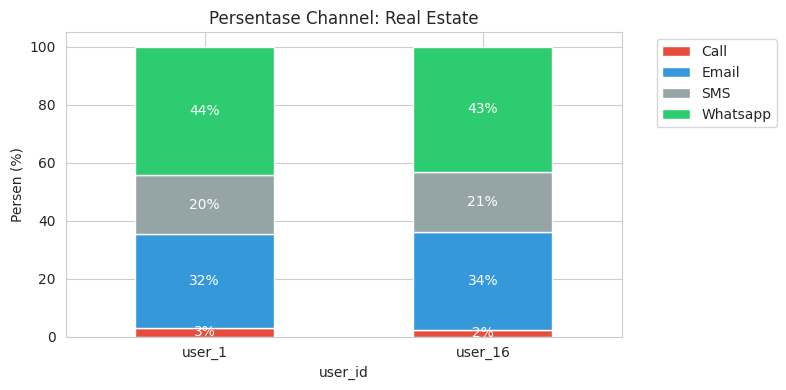

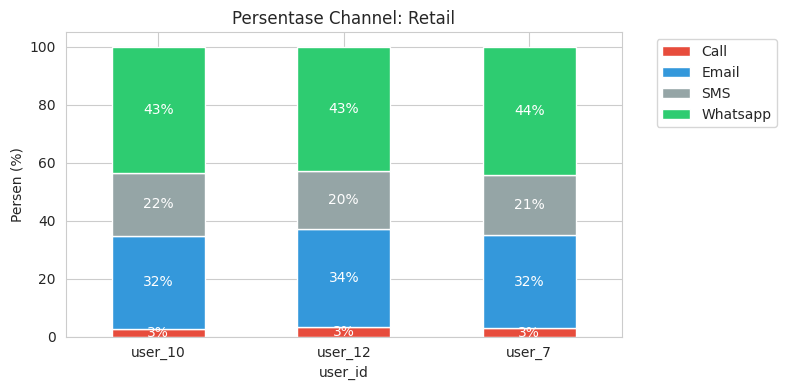

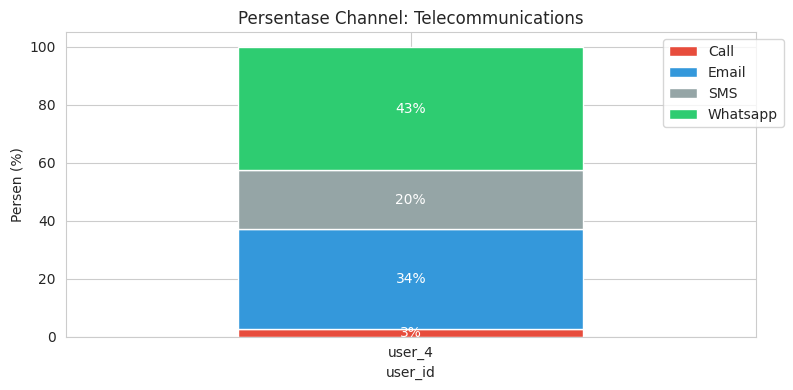

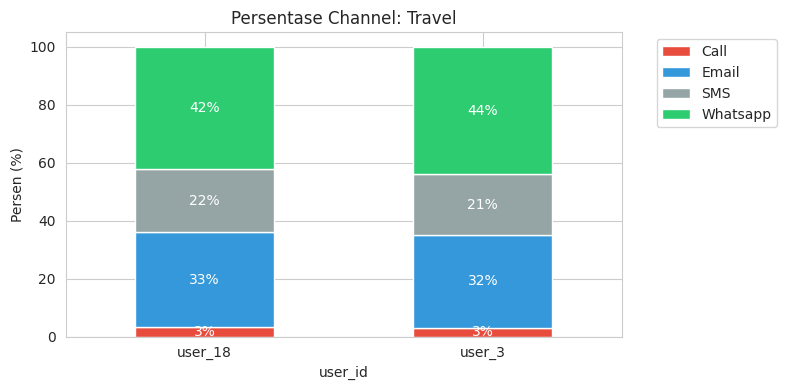

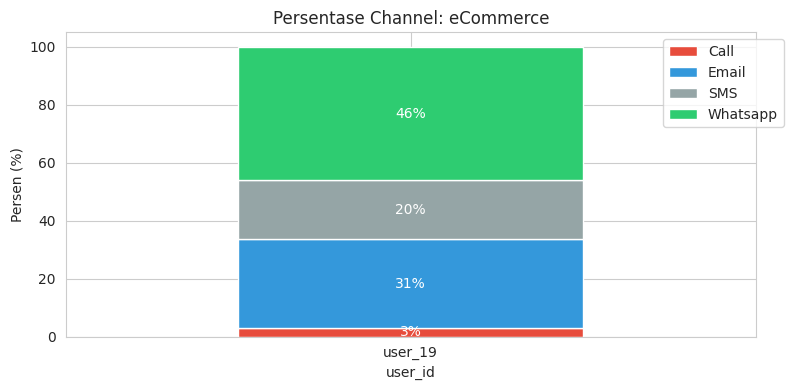

In [75]:
# visualisasi
industries = usage['field_of_business'].unique()

for ind in industries:
  data_ind = usage[usage['field_of_business'] == ind]

  # pivot biar siap di plot
  pivot_chart = data_ind.pivot(index='user_id', columns='channel', values='percentage').fillna(0)

  # Plot
  ax = pivot_chart.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#e74c3c', '#3498db', '#95a5a6', '#2ecc71']) #colormap='viridis')
  plt.title(f'Persentase Channel: {ind}')
  plt.ylabel('Persen (%)')
  plt.xticks(rotation=0)

  for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white')

  plt.legend(bbox_to_anchor=(1.05, 1))
  plt.tight_layout()
  plt.show()

# **Describe Segmentation**

POWER USER


(The Whales)

• Most Profitable: Rata-rata omset Rp 2,7 Juta (8 User).


• Pattern: Volume tinggi, aktif 24 jam (indikasi Bot/Sistem Otomatis).


• Churn Risk: 🚨 CRITICAL. Tren pemakaian turun rata-rata -24.7%. User top seperti user_2 & user_1 mulai mengurangi traffic.


• Channel: Multi-channel heavy users.

• PRIORITY #1 (Personal): Segera telepon! Jangan pakai email. Tanya kendala teknis mereka.


• OPTIMIZATION: Pindahkan rute SMS/WA mereka ke jalur Direct Premium yang stabil agar mereka tidak kecewa.


• LOCK-IN: Tawarkan SLA (Jaminan Uptime) & Diskon Volume agar tidak pindah ke kompetitor.

LOYAL USER


(Regulars)

• Profit: Menengah, rata-rata omset Rp 327 Ribu (8 User).


• Pattern: Volume sedang, aktif di jam kerja (Human/Manual).


• Churn Risk: ⚠️ HIGH. Penurunan pemakaian cukup dalam (-25%).


• Channel: Multi-channel tapi volume belum maksimal.

• RE-ENGAGEMENT: Kirim voucher "We Miss You" (Saldo Rp 20rb) untuk memancing mereka aktif lagi.


• EDUCATION: Berikan tips cara broadcast yang efektif lewat WA/Email.


• UPSELL: Tawarkan paket bundling kecil (misal: Beli 1000 SMS bonus 100 WA).

CASUAL USER


(Small Fish)

• Profit: Kecil, rata-rata omset Rp 324 Ribu (4 User).


• Pattern: Volume rendah, kadang aktif kadang tidak.


• Churn Risk: MODERATE. Tren turun -28%, tapi dampaknya ke total omset minim.


• Channel: Cenderung sensitif harga.

• AUTOMATION: Masukkan ke list email marketing rutin (Newsletter). Jangan habiskan waktu tim sales di sini.


• NURTURE: Jaga hubungan dengan konten ringan.


• SELF-SERVICE: Arahkan mereka untuk top-up mandiri via web/app.

# 1

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

NameError: name 'rfm' is not defined

In [ ]:
# Analisis Hasil
cluster_summary = rfm.groupby('Cluster').agg({
    'user_id': 'count', # julah user
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean'
}).sort_values(by='Monetary', ascending=False).reset_index()

print("=== Hasil Clustering Paling Profitable===")
print(cluster_summary)

In [ ]:
# Scoring 1 - 3
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=3, labels=[3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1, 2, 3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=3, labels=[1, 2, 3])
# Mix Scoring (Total score maksimal 3+3+3 = 9)
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

In [ ]:
# Segmentasi User
def assign_segment(row):
  score = row['RFM_Score']
    if score >= 8:
        return 'Power User'
    elif score >= 5:
        return 'Moderate User'
    else:
        return 'Dormant User'

In [ ]:
# scaterplot F&M_score
plt.scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.5)
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Scatterplot Frequency vs Monetary')
plt.show()


In [ ]:
# scatterplot F&Mscore logscale
plt.scatter((rfm['Frequency']),np.log1p(rfm['Monetary']), alpha=0.5)
plt.xlabel('Log Frequency')
plt.ylabel('Log Monetary')
plt.title('Scatterplot Log Frequency vs Log Monetary')

In [ ]:
# Top Cluster
best_cluster_id = cluster_summary.loc[0]['Cluster']
best_users = rfm[rfm['Cluster'] == best_cluster_id]

print(f"\n=== Top Users Cluster {best_cluster_id} ===")
print(f"Jumlah User: {len(best_users)}")
print(best_users.sort_values(by='Monetary', ascending=False))

In [ ]:
# Business & Channel profitable
top_business_best_cluster = best_users['field_of_business'].value_counts().head(5)

best_user_ids = best_users['user_id'].unique()
best_transactions = df_clean[df_clean['user_id'].isin(best_user_ids)]

top_channel = best_transactions.groupby('channel')['total_price'].sum().sort_values(ascending=False)

print("\n===Top Business====")
print(top_business_best_cluster)

print("\n===Top Channel====")
print(top_channel)


* RFM: Ini teknik standar bank/telco buat nilai customer value.

* Scaler: Biar K-Means gak bingung ngitung jarak (karena duit angkanya jutaan, frekuensi cuma puluhan, kalau gak di-scale, duit bakal mendominasi banget).

* Cluster Summary: Bagian ini yang ngasih tau kita cluster mana yang "Sultan", mana yang biasa aja.

# Utopia

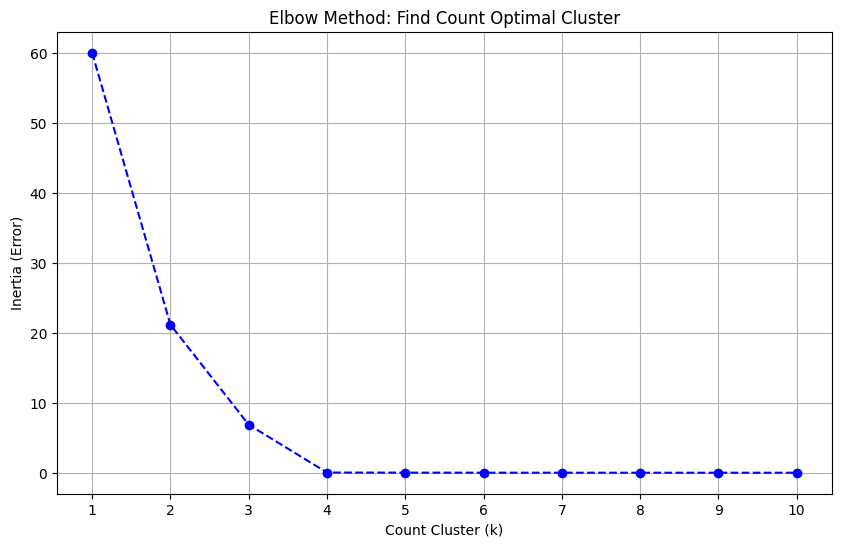

In [ ]:
user_rfm = df_OCA.groupby('user_id').agg({
    'transaction_id': 'count',           # Frequency
    'total_price': 'sum',                # Monetary
    'created_at': lambda x: x.dt.date.nunique() # Active Days
}).reset_index()

user_rfm.rename(columns={
    'transaction_id': 'frequency',
    'total_price': 'monetary',
    'created_at': 'active_days'
}, inplace=True)

# 2. PREPROCESSING (Standardisasi)
# Log Transform untuk data yang jomplang (Frequency & Monetary)
user_rfm['log_frequency'] = np.log1p(user_rfm['frequency'])
user_rfm['log_monetary'] = np.log1p(user_rfm['monetary'])

# Pilih fitur untuk clustering
features = ['log_frequency', 'log_monetary', 'active_days']
X = user_rfm[features]

# Scale data agar satuannya setara
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. JALANKAN ELBOW METHOD
inertia = []
K_range = range(1, 11) # Coba k dari 1 sampai 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 4. VISUALISASI GRAFIK
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method: Find Count Optimal Cluster')
plt.xlabel('Count Cluster (k)')
plt.ylabel('Inertia (Error)')
plt.xticks(K_range)
plt.grid(True)
plt.show() # Akan menampilkan grafik siku

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 11)  # silhouette TIDAK bisa untuk k=1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)



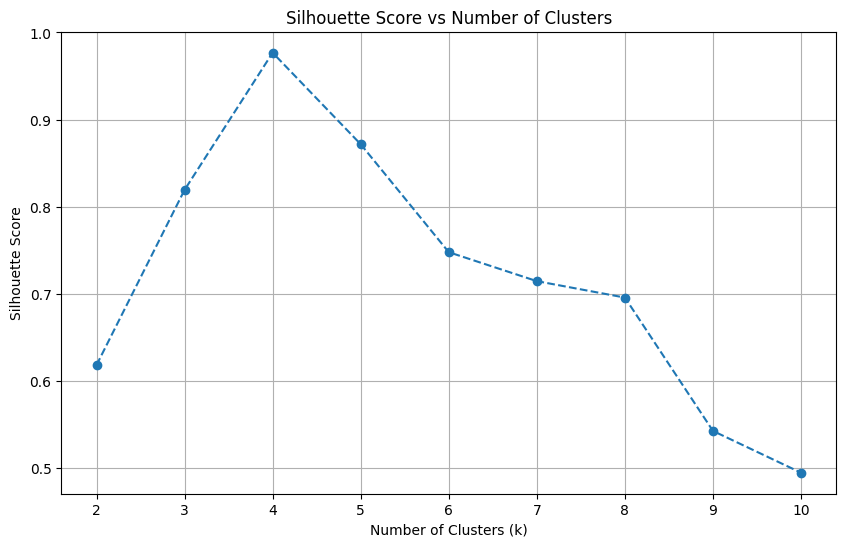

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
# Check if Recency values are all the same. If so, assign a uniform high score.
if rfm['Recency'].nunique() == 1:
    rfm['R'] = 4  # Assign the highest Recency score if all are equally recent
else:
    rfm['R'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])

rfm['F'] = pd.qcut(rfm['Frequency'], q=4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

rfm[['R','F','M']] = rfm[['R','F','M']].astype(int)

In [ ]:
rfm['RFM_score'] = (
    0.2 * rfm['R'] +
    0.4 * rfm['F'] +
    0.4 * rfm['M']
)

def rfm_segment(row):
    if row['RFM_score'] >= 3.5:
        return 'High Value'
    elif row['RFM_score'] >= 2.5:
        return 'Mid Value'
    else:
        return 'Low Value'

### **RFM Segmentasi**

In [ ]:
# RFM Segmentation

# prepare RFM
df_OCA['created_at'] = pd.to_datetime(df_OCA['created_at'], errors='coerce')

snapshot_date = df_OCA['created_at'].max() + pd.Timedelta(days=1)

rfm = df_OCA.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days, # Recency
    'usage_frequency': 'count',                             # Frequency
    'total_price' : 'sum'                                     # Monetary
}).reset_index()

rfm.columns = ['user_id', 'Recency', 'Frequency', 'Monetary']

In [ ]:
# Check if Recency values are all the same. If so, assign a uniform high score.
if rfm['Recency'].nunique() == 1:
    rfm['R'] = 4  # Assign the highest Recency score if all are equally recent
else:
    rfm['R'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])

rfm['F'] = pd.qcut(rfm['Frequency'], q=4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

rfm[['R','F','M']] = rfm[['R','F','M']].astype(int)

In [ ]:
# Scoring
rfm['RFM_score'] = (
    0.2 * rfm['R'] +
    0.4 * rfm['F'] +
    0.4 * rfm['M']
)

In [ ]:
def rfm_segment(row):
    if row['RFM_score'] >= 3.5:
        return 'High Value'
    elif row['RFM_score'] >= 2.5:
        return 'Mid Value'
    else:
        return 'Low Value'

# Apply the segmentation function to the 'rfm' DataFrame
rfm['rfm_segment'] = rfm.apply(rfm_segment, axis=1)

# Merge the segment back to df_OCA
df_OCA = df_OCA.merge(rfm[['user_id', 'rfm_segment']], on='user_id', how='left')


In [ ]:
# tampilkan rfm
print(df_OCA[['user_id', 'rfm_segment']].value_counts())

user_id  rfm_segment
user_3   High Value     24634
user_2   High Value     24518
user_1   High Value     24496
user_4   High Value      6230
user_5   High Value      6198
user_7   High Value      6132
user_8   Mid Value       6117
user_6   Mid Value       6010
user_16  Mid Value       1593
user_18  Mid Value       1573
user_11  Low Value       1559
user_20  Mid Value       1554
user_19  Low Value       1552
user_13  Low Value       1530
user_10  Low Value       1525
user_14  Low Value       1523
user_9   Low Value       1519
user_17  Low Value       1510
user_15  Low Value       1488
user_12  Low Value       1487
Name: count, dtype: int64


In [ ]:
# RFM Segmentation

# prepare RFM
df_OCA['created_at'] = pd.to_datetime(df_OCA['created_at'], errors='coerce')

snapshot_date = df_OCA['created_at'].max() + pd.Timedelta(days=1)

rfm = df_OCA.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days, # Recency
    'usage_frequency': 'count',                             # Frequency
    'total_price' : sum                                     # Monetary
}).reset_index()

rfm.columns = ['user_id', 'Recency', 'Frequency', 'Monetary']

/tmp/ipython-input-2438870491.py:8: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  rfm = df_OCA.groupby('user_id').agg({


In [ ]:
# RFM scoring
# Since all users have the same 'Recency' value (1), meaning they are all equally recent,
# we assign the highest R_Score (5) to all of them.
rfm['R_Score'] = 5
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

In [ ]:
# segment label

def rfm_segment(row):
    if row['RFM_Score'] >= 13:
        return 'Power User'
    elif row['R_Score'] <= 2:
        return 'At Risk'
    elif row['F_Score'] >= 4 and row['M_Score'] <= 2:
        return 'Frequent Low Value'
    else:
        return 'Regular'

# Apply the segmentation function to the 'rfm' DataFrame
rfm['rfm_segment'] = rfm.apply(rfm_segment, axis=1)

# Merge the segment back to df_OCA
df_OCA = df_OCA.merge(rfm[['user_id', 'rfm_segment']], on='user_id', how='left')

print(df_OCA[['user_id', 'rfm_segment']].value_counts())

KeyError: "['rfm_segment'] not in index"

## PERSONALIZATION


In [ ]:
df_OCA['hour'] = pd.to_datetime(df_OCA['created_at']).dt.hour

active_hour = (df_OCA.groupby(['user_id', 'hour'])
               .size()
               .reset_index()
               .rename(columns={0: 'cnt'})
               .sort_values(['user_id', 'cnt'], ascending=[True, False])
               .drop_duplicates('user_id'))

In [ ]:
active_hour

,user_id,hour,cnt
6,user_1,17,2037
21,user_10,19,134
30,user_11,15,153
51,user_12,23,139
60,user_13,19,140
76,user_14,22,139
89,user_15,22,134
101,user_16,21,146
110,user_17,17,132
122,user_18,16,143


In [ ]:
# extract time to day & hour
df_OCA['day_name'] = df_OCA['created_at'].dt.day_name() # hari
df_OCA['hour'] = df_OCA['created_at'].dt.hour # jam

In [ ]:
# Agregasi
def get_mode(x):
  return x.mode().iloc[0] if not x.mode().empty else None

In [ ]:
# Grouping per User
user_behavior_v2 = df_OCA.groupby('user_id').agg({
    'channel': 'nunique',                             # Channel diversity (Count Distinct)
    'transaction_id': 'count',                        # Message volume (Total)
    'created_at': lambda x: x.dt.date.nunique(),      # Usage Frequency (Active Days Count)
    'day_name': get_mode,                             # Most active day
    'hour': get_mode,                                 # Most active hour
}).reset_index()

In [ ]:
# Rename grouping
user_behavior_v2.rename(columns={
    'channel': 'channel_diversity',
    'transaction_id': 'message_volume',
    'created_at': 'usage_frequency',
    'day_name': 'most_active_day',
    'hour': 'most_active_hour'
}, inplace=True)

In [ ]:
print(user_behavior_v2.head().sort_values('message_volume', ascending=True))

   user_id  channel_diversity  message_volume  usage_frequency  \
3  user_12                  4            1487               91   
1  user_10                  4            1525               91   
4  user_13                  4            1530               90   
2  user_11                  4            1559               90   
0   user_1                  4           24496               91   

  most_active_day  most_active_hour  
3          Friday                23  
1          Friday                19  
4          Sunday                19  
2        Thursday                15  
0        Thursday                17  


In [ ]:
user_behavior_v2.describe()

,channel_diversity,message_volume,usage_frequency,most_active_hour
count,20.0,20.000000,20.000000,20.000000
mean,4.0,6137.400000,90.700000,18.050000
std,0.0,8179.882076,0.470162,4.999737
min,4.0,1487.000000,90.000000,0.000000
25%,4.0,1524.500000,90.000000,16.000000
50%,4.0,1566.000000,91.000000,19.000000
75%,4.0,6148.500000,91.000000,21.250000
max,4.0,24634.000000,91.000000,23.000000


feture scalling

<Axes: >

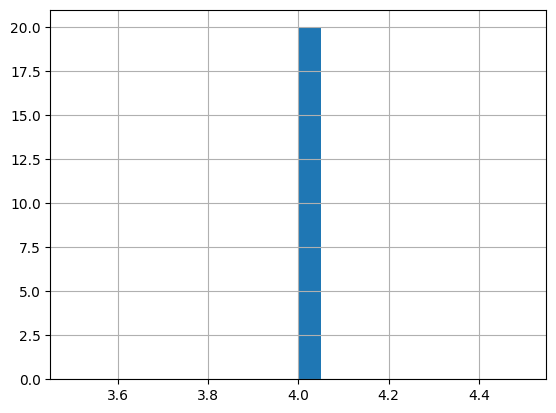

In [ ]:
# channel diversity
user_behavior_v2['channel_diversity'].hist(bins=20)

In [ ]:
user_behavior_v2['rece'].hist(bins=20)

KeyError: 'rece'

### **Which segment is most profitable ?**

In [ ]:
user_df = df_OCA.groupby('user_id').agg({
    'total_price': 'sum',             # Total Revenue
    'transaction_id': 'count',         # Volume Message
    'created_at': lambda x: x.dt.date.nunique() # Usage Frequency
}).reset_index()

In [ ]:
# rename user_df
user_df.rename(columns={
    'total_price': 'total_revenue',
    'transaction_id': 'volume_message',
    'created_at': 'usage_frequency'
}, inplace=True)

**Feature Scalling**

**Log Transform + Standart Scaling** because The data is severely skewed (exponentially). It needs to be logged to normalize it.

In [ ]:
# feature scalling volume_message
user_df['volume_message'].hist(bins=20)

In [ ]:
# Log Transformation because the difference in the figures is huge
user_df['log_volume'] = np.log1p(user_df['volume_message'])

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standart Scalling
scaler = StandardScaler()
feature_cluster = ['log_volume', 'usage_frequency']
user_df[feature_cluster] = scaler.fit_transform(user_df[feature_cluster])

In [ ]:
user_df[feature_cluster].head()

In [ ]:
# feature scalling feature_cluster
user_df[feature_cluster].hist(bins=20)

**Clustering**

#### **K-Means**

In [ ]:
from sklearn.cluster import KMeans

# set 3 cluster (low, mid, high value)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
user_df['cluster'] = kmeans.fit_predict(user_df[feature_cluster])

In [ ]:
user_df['cluster'].value_counts()

In [ ]:
# Analisis hasil
summary = user_df.groupby('cluster').agg({
    'user_id': 'count',
    'total_revenue': 'mean',
    'volume_message': 'mean',
    'usage_frequency': 'mean'
}).reset_index()

In [ ]:
# summary
summary = summary.sort_values('total_revenue', ascending=False).reset_index(drop=True)

summary['Segment_label'] = ['Low Whales (VIP)', 'Mid Value', 'At-Risk/Low Value']

print("=== Hasil Segementasi K-Means (diurutkan berdasarkan Profit) ===")
print(summary[['Segment_label', 'user_id', 'total_revenue', 'volume_message', 'usage_frequency']])

#### **RFM - 3 segments**

In [ ]:
rfm = df.groupby('user_id').agg({
    'created_at': lambda x: (current_date - x.max()).days, # Recency
    'transaction_id': 'count',                             # Frequency
    'total_price': 'sum',                                  # Monetary
}).reset_index()

In [ ]:
rfm.rename(columns={
    'created_at': 'recency_days',
    'transaction_id': 'frequency_trx',
    'total_price': 'monetary_value'
}, inplace=True)

In [ ]:
# Scoring
# Frequency & Monetary semakin besar semakin baik 1 -> 2 -> 3
rfm['F_score'] = pd.qcut(rfm['frequency_trx'], q=3, labels=[1, 2, 3,])
rfm['M_score'] = pd.qcut(rfm['monetary_value'], q=3, labels=[1, 2, 3])

# Recency semakin kecil semakin bagus 3 -> 2 -> 1
try:
  rfm['R_score'] = pd.qcut(rfm['recency_days'], q=3, labels=[3, 2, 1])
except ValueError:
  rfm['R_score'] = 3

In [ ]:
# Segmen labeling
rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Atau pakai Logic Sederhana: Rata-rata Skor FM (karena R statis)
rfm['FM_Average'] = (rfm['F_score'].astype(int) + rfm['M_score'].astype(int)) / 2

def segment_user(score):
    if score >= 3:
        return 'Power user'
    elif score >= 2:
        return 'Moderate Users'
    else:
        return 'Dormant Users'

rfm['Segment_Label'] = rfm['FM_Average'].apply(segment_user)

# Urutkan dari yang paling Sultan
print(rfm[['user_id', 'recency_days', 'frequency_trx', 'monetary_value', 'RFM_Segment', 'Segment_Label']].sort_values('monetary_value', ascending=False))

In [ ]:
rfm.value_counts('Segment_Label').sort_index(ascending=True)

In [ ]:
profit_analysis = rfm.groupby('Segment_Label').agg({
    'user_id': 'count',                 # Total user
    'monetary_value': ['sum', 'mean'],  # Total & average value
}).reset_index()

profit_analysis.columns = ['Segment_Label', 'Total_User', 'Total_Profit', 'Average_Profit_per_User']

profit_analysis = profit_analysis.sort_values('Total_Profit', ascending=False)

print(profit_analysis)

In [ ]:
totalprofit = profit_analysis['Total_Profit'].sum()
print(f"Total Profit : {totalprofit}")

In [ ]:
# which field business of power user


**Result**

Dengan clustering RFM didapat :
* Which segment is most profitable is segment  Power user with total profit **9537950** with average per user **1362564**       

In [ ]:
df.info()

In [ ]:
df_OCA.info()

## a

In [ ]:
# feature scalling total price
user_df['total_revenue'].hist(bins=20)

In [ ]:
from sklearn.preprocessing import StandardScaler

# standard scaling volume_message

volume_message_scaled = StandardScaler().fit_transform(user_df[['volume_message']])

print("min:", np.min(volume_message_scaled))
print("max:", np.max(volume_message_scaled))
print("diff:", np.max(volume_message_scaled) - np.min(volume_message_scaled))

# so min and max to 1
volume_message_scaled = volume_message_scaled/(np.max(volume_message_scaled) - np.min(volume_message_scaled))

pd.DataFrame(volume_message_scaled).hist(bins=20)

In [ ]:
user_df[['volume_message']].boxplot()

In [ ]:
# feature scalling usage_frequency
user_df['usage_frequency'].hist(bins=20)

Join Preferred channel, channel diversity, time behavior to df_OCA

In [ ]:
# Join Preferred channel & channel diversity to df_OCA

# preferred_channel is already a DataFrame. Rename its 'channel' and 'cnt' columns for clarity in df_OCA.
preferred_channel_for_merge = preferred_channel.rename(columns={'channel': 'preferred_channel', 'cnt': 'preferred_channel_count'})
df_OCA = df_OCA.merge(preferred_channel_for_merge[['user_id', 'preferred_channel', 'preferred_channel_count']], on='user_id', how='left')

# channel_diversity is a Series, so .to_frame() is valid here to create a DataFrame for merging.
df_OCA = df_OCA.merge(channel_diversity.to_frame('channel_diversity'), on='user_id', how='left')

# active_hour
df_OCA = df_OCA.merge(active_hour[['user_id', 'hour']], on='user_id', how='left')

In [ ]:
# Grouping status success
success_status = ['delivered', 'read', 'clicked', 'opened', 'answered', 'sent']
df_OCA['is_success'] = df_OCA['message_status'].isin(success_status).astype(int)

In [ ]:
# Grouping per user id
user_behavior = df_OCA.groupby('user_id').agg({
    'created_at': lambda x: (current_date - x.max()).days, # Recency
    'transaction_id': 'count',                             # Frequency
    'total_price': 'sum',                                  # Monetary
    'is_success': 'mean',                                  # Success Rate (Rata-rata sukses)
    'channel': lambda x: x.mode()[0],                      # Preferred Channel
    'tenure': 'max',                                       # Lama langganan (hari)
    'field_of_business': 'first'                           # Buat profil bisnisnya
}).reset_index()

In [ ]:
# rename kolom user behavior
user_behavior.rename(columns={
    'created_at': 'recency_days',
    'transaction_id': 'frequency_trx',
    'total_price': 'monetary value',
    'is_success': 'success_rate',
    'channel': 'preferred_channel'
}, inplace=True)

print(user_behavior.head())

**Found in Analyst**
* all users use omnichannel, using all channel
* channel whatsapp more commonly used

Simpan df_OCA untuk Visualisasi


In [ ]:
# simpan df_OCA
df_OCA.to_csv('df_OCA.csv', index=False)

#### noise

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

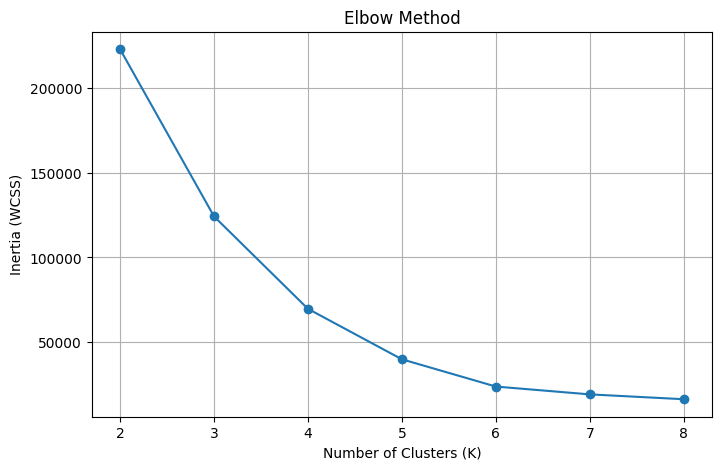

In [ ]:
X = df_scaled[num_features]

inertia = []
K_range = range(2, 9)  # aman untuk n=20

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(True)
plt.show()


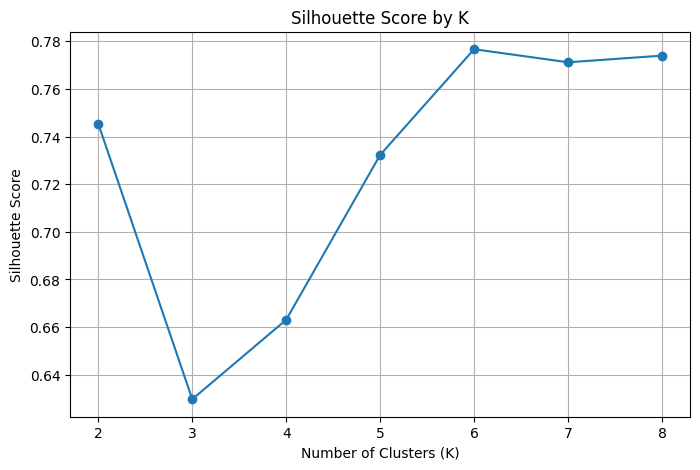

In [ ]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

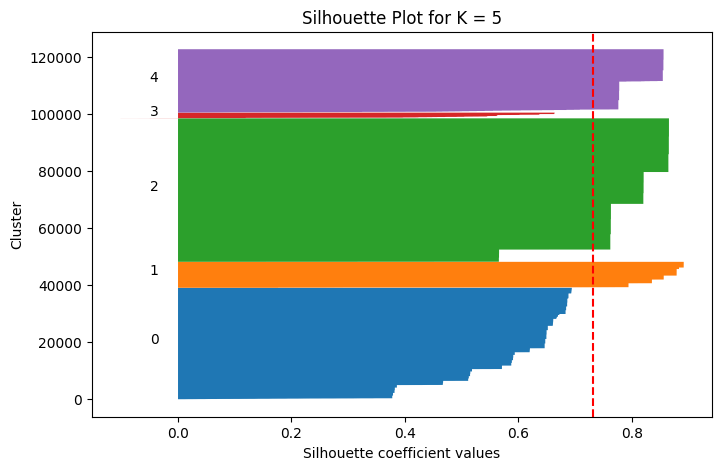

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

sample_silhouette_values = silhouette_samples(X, labels)

plt.figure(figsize=(8,5))
y_lower = 10

for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster")
plt.title(f"Silhouette Plot for K = {k}")
plt.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")
plt.show()

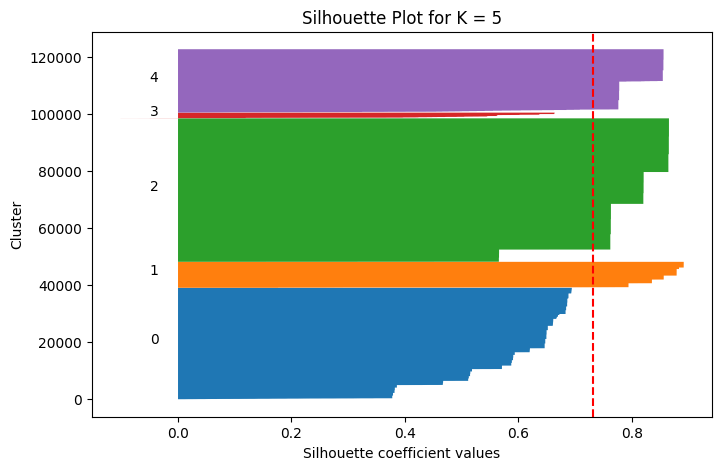

In [ ]:
from sklearn.metrics import silhouette_samples
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

sample_silhouette_values = silhouette_samples(X, labels)

plt.figure(figsize=(8,5))
y_lower = 10

for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster")
plt.title(f"Silhouette Plot for K = {k}")
plt.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")
plt.show()

**Statistically, it is very valid to divide users into four main segments.**

In [ ]:
# Which most profit
profitability = (
    df.groupby("segment")
      .agg({
          "message_volume": "mean",
          "usage_frequency": "mean",
          "channel_diversity": "mean"
      })
      .sort_values("message_volume", ascending=False)
)

print(profitability)

In [ ]:
# Sort dari yang paling bahaya
report = churn_risk[['user_id', 'churn_probability', 'usage_trend', 'failure_rate', 'avg_daily_last_7d', 'avg_daily_prev']]
report = report.sort_values(by=['churn_probability', 'usage_trend'], ascending=[True, True])

# Formatting
report['usage_trend'] = report['usage_trend'].apply(lambda x: f"{x:.1%}")
report['failure_rate'] = report['failure_rate'].apply(lambda x: f"{x:.1%}")
report['avg_daily_last_7d'] = report['avg_daily_last_7d'].apply(lambda x: f"{x:.1f}")
report['avg_daily_prev'] = report['avg_daily_prev'].apply(lambda x: f"{x:.1f}")

print("=== LAPORAN PREDIKSI CHURN (RISK ANALYSIS) ===")
print(report)

=== LAPORAN PREDIKSI CHURN (RISK ANALYSIS) ===
    user_id          churn_probability usage_trend failure_rate  \
2   user_11  High Risk (Quality Issue)      -43.8%        74.2%   
19   user_9  High Risk (Quality Issue)      -37.0%        74.9%   
3   user_12  High Risk (Quality Issue)      -35.9%        75.7%   
10  user_19  High Risk (Quality Issue)      -34.8%        76.9%   
5   user_14  High Risk (Quality Issue)      -32.8%        73.9%   
16   user_6  High Risk (Quality Issue)      -31.0%        74.7%   
18   user_8  High Risk (Quality Issue)      -30.4%        75.2%   
8   user_17  High Risk (Quality Issue)      -30.2%        73.4%   
11   user_2  High Risk (Quality Issue)      -28.2%        74.9%   
4   user_13  High Risk (Quality Issue)      -26.2%        74.5%   
12  user_20  High Risk (Quality Issue)      -24.5%        75.0%   
14   user_4  High Risk (Quality Issue)      -23.8%        75.3%   
17   user_7  High Risk (Quality Issue)      -22.9%        75.8%   
0    user_1  Hi

# its just something

In [ ]:
# Dominant Channel
dominant_channel = (
    df_OCA
    .groupby(['user_id', 'channel'])
    .size()
    .reset_index(name='msg_count')
    .sort_values(['user_id', 'msg_count'], ascending=[True, False])
    .drop_duplicates('user_id')
    .rename(columns={'channel': 'dominant_channel'})
    [['user_id', 'dominant_channel']]
)
print(dominant_channel)

    user_id dominant_channel
3    user_1         Whatsapp
7   user_10         Whatsapp
11  user_11         Whatsapp
15  user_12         Whatsapp
19  user_13         Whatsapp
23  user_14         Whatsapp
27  user_15         Whatsapp
31  user_16         Whatsapp
35  user_17         Whatsapp
39  user_18         Whatsapp
43  user_19         Whatsapp
47   user_2         Whatsapp
51  user_20         Whatsapp
55   user_3         Whatsapp
59   user_4         Whatsapp
63   user_5         Whatsapp
67   user_6         Whatsapp
71   user_7         Whatsapp
75   user_8         Whatsapp
79   user_9         Whatsapp


In [ ]:

channel_view = pd.crosstab(df_OCA['user_id'], df_OCA['channel'])
channel_view['dominant_channel'] = channel_view.idxmax(axis=1)

# Count score dominations (%)
channel_view ['total_transaction'] = channel_view.sum(axis=1, numeric_only=True)
channel_view ['max_transaction'] = channel_view.max(axis=1, numeric_only=True)
channel_view ['dominant_score'] = (channel_view['max_transaction'] / channel_view['total_transaction']).round(2)

show = ['Whatsapp','SMS','Email','Call','dominant_channel','dominant_score']
print(channel_view[show].sort_values('dominant_score', ascending=False))
print(channel_view['total_transaction'])

channel  Whatsapp   SMS  Email  Call dominant_channel  dominant_score
user_id                                                              
user_1      10037  3960   7938  2561         Whatsapp             1.0
user_10       613   259    492   161         Whatsapp             1.0
user_11       639   260    500   160         Whatsapp             1.0
user_12       588   234    499   166         Whatsapp             1.0
user_13       625   257    480   168         Whatsapp             1.0
user_14       620   226    516   161         Whatsapp             1.0
user_15       618   251    468   151         Whatsapp             1.0
user_16       644   263    530   156         Whatsapp             1.0
user_17       646   230    473   161         Whatsapp             1.0
user_18       629   270    509   165         Whatsapp             1.0
user_19       656   246    493   157         Whatsapp             1.0
user_2       9920  3989   8107  2502         Whatsapp             1.0
user_20       636   

In [ ]:
# Add Voice Ratio
voice_ratio = (
    df_OCA
    .assign(is_call=lambda x: (x['channel'] == 'Call').astype(int))
    .groupby('user_id')
    .agg(
        total_tx=('channel', 'count'),
        call_tx=('is_call', 'sum')
    )
    .reset_index()
)

voice_ratio['voice_ratio'] = voice_ratio['call_tx'] / voice_ratio['total_tx']

print(voice_ratio)

    user_id  total_tx  call_tx  voice_ratio
0    user_1     24496     2561     0.104548
1   user_10      1525      161     0.105574
2   user_11      1559      160     0.102630
3   user_12      1487      166     0.111634
4   user_13      1530      168     0.109804
5   user_14      1523      161     0.105712
6   user_15      1488      151     0.101478
7   user_16      1593      156     0.097928
8   user_17      1510      161     0.106623
9   user_18      1573      165     0.104895
10  user_19      1552      157     0.101160
11   user_2     24518     2502     0.102047
12  user_20      1554      154     0.099099
13   user_3     24635     2586     0.104973
14   user_4      6230      639     0.102568
15   user_5      6198      639     0.103098
16   user_6      6010      658     0.109484
17   user_7      6132      648     0.105675
18   user_8      6117      603     0.098578
19   user_9      1519      153     0.100724


In [ ]:
# add avg_ticket_size
df_tx = (
    df_OCA
    .sort_values('created_at')
    .drop_duplicates(subset='transaction_id', keep='last')
)

avg_ticket_size = (
    df_tx
    .groupby('user_id')
    .agg(
        total_revenue=('price', 'sum'),
        total_tx=('transaction_id', 'count')
    )
    .reset_index()
)

avg_ticket_size['avg_ticket_size'] = (
    avg_ticket_size['total_revenue'] / avg_ticket_size['total_tx']
)

print(avg_ticket_size)

    user_id  total_revenue  total_tx  avg_ticket_size
0    user_1        1970000     24496        80.421293
1   user_10         129500      1525        84.918033
2   user_11         130000      1559        83.386786
3   user_12         117000      1487         78.68191
4   user_13         128500      1530        83.986928
5   user_14         112500      1523        73.867367
6   user_15         125500      1488        84.341398
7   user_16         131500      1593         82.54865
8   user_17         115000      1510         76.15894
9   user_18         134500      1573        85.505404
10  user_19         123000      1552        79.252577
11   user_2        1987000     24518        81.042499
12  user_20         129500      1554        83.333333
13   user_3        2018500     24634        81.939596
14   user_4         495000      6230        79.454254
15   user_5         509500      6198        82.203937
16   user_6         480000      6010        79.866889
17   user_7         507000  

In [ ]:
# add recency days
snapshot_date = pd.Timestamp('2025-04-01').tz_localize('Asia/Jakarta')

recency_days = (
    df_OCA
    .groupby('user_id')['created_at']
    .max()
    .reset_index(name='last_transaction_date')
)

recency_days['recency_days'] = (
    snapshot_date - recency_days['last_transaction_date']
).dt.days

print(recency_days)

    user_id     last_transaction_date  recency_days
0    user_1 2025-04-01 03:59:00+07:00            -1
1   user_10 2025-04-01 00:20:00+07:00            -1
2   user_11 2025-03-31 23:24:00+07:00             0
3   user_12 2025-04-01 01:06:00+07:00            -1
4   user_13 2025-03-31 22:43:00+07:00             0
5   user_14 2025-03-31 20:13:00+07:00             0
6   user_15 2025-03-31 21:45:00+07:00             0
7   user_16 2025-04-01 01:11:00+07:00            -1
8   user_17 2025-03-31 23:16:00+07:00             0
9   user_18 2025-04-01 02:51:00+07:00            -1
10  user_19 2025-03-31 22:41:00+07:00             0
11   user_2 2025-04-01 03:55:00+07:00            -1
12  user_20 2025-04-01 00:28:00+07:00            -1
13   user_3 2025-04-01 03:50:00+07:00            -1
14   user_4 2025-04-01 02:32:00+07:00            -1
15   user_5 2025-04-01 03:48:00+07:00            -1
16   user_6 2025-04-01 02:56:00+07:00            -1
17   user_7 2025-04-01 03:43:00+07:00            -1
18   user_8 

In [ ]:
# Tenure
tenure = (
    df_OCA
    .groupby('user_id')['created_at']
    .min()
    .reset_index(name='join_date')
    .assign(
        join_date=lambda x: x['join_date'].dt.tz_convert('Asia/Jakarta')
    ))

tenure['tenure'] = (snapshot_date - tenure['join_date']).dt.days

print(tenure)

    user_id                 join_date  tenure
0    user_1 2025-01-01 15:01:00+07:00      89
1   user_10 2025-01-01 15:19:00+07:00      89
2   user_11 2025-01-01 15:31:00+07:00      89
3   user_12 2025-01-01 16:09:00+07:00      89
4   user_13 2025-01-01 15:16:00+07:00      89
5   user_14 2025-01-01 15:16:00+07:00      89
6   user_15 2025-01-01 15:06:00+07:00      89
7   user_16 2025-01-01 15:29:00+07:00      89
8   user_17 2025-01-01 17:26:00+07:00      89
9   user_18 2025-01-01 15:13:00+07:00      89
10  user_19 2025-01-01 15:01:00+07:00      89
11   user_2 2025-01-01 15:01:00+07:00      89
12  user_20 2025-01-01 15:22:00+07:00      89
13   user_3 2025-01-01 15:00:00+07:00      89
14   user_4 2025-01-01 15:00:00+07:00      89
15   user_5 2025-01-01 15:36:00+07:00      89
16   user_6 2025-01-01 15:04:00+07:00      89
17   user_7 2025-01-01 15:10:00+07:00      89
18   user_8 2025-01-01 15:02:00+07:00      89
19   user_9 2025-01-01 15:21:00+07:00      89


In [ ]:
# is_dormant
start_date = '2025-01-01'
end_date = '2025-04-01'

# Logic: Ambil dari tgl 1 Jan sampai SEBELUM tgl 2 April (biar 1 April jam 23:59 tetap masuk)
mask = (df['created_at'] >= start_date) & (df['created_at'] < '2025-04-02')
df_filtered = df.loc[mask].copy()

# 3. SET ANCHOR DATE (Titik "Hari Ini")
# Kita pakai tanggal maksimal di data yang SUDAH difilter sebagai patokan
current_date = df_filtered['created_at'].max()

# 4. HITUNG RECENCY PER USER
user_status = df_filtered.groupby('user_id').agg({
    'created_at': lambda x: (current_date - x.max()).days
}).reset_index()

user_status.rename(columns={'created_at': 'recency_days'}, inplace=True)

# 5. TENTUKAN STATUS DORMANT (> 14 Hari)
user_status['is_dormant'] = user_status['recency_days'] > 14

# Cek Hasil
print(f"Data Date Range: {df_filtered['created_at'].min()} s/d {df_filtered['created_at'].max()}")
print("\nUser Status Sample:")
print(user_status)
print("\nJumlah User Dormant:")
print(user_status['is_dormant'].value_counts())

Data Date Range: 2025-01-01 15:00:00+07:00 s/d 2025-03-31 03:57:00+07:00

User Status Sample:
    user_id  recency_days  is_dormant
0    user_1             0       False
1   user_10             0       False
2   user_11             0       False
3   user_12             0       False
4   user_13             0       False
5   user_14             0       False
6   user_15             0       False
7   user_16             0       False
8   user_17             0       False
9   user_18             0       False
10  user_19             0       False
11   user_2             0       False
12  user_20             0       False
13   user_3             0       False
14   user_4             0       False
15   user_5             0       False
16   user_6             0       False
17   user_7             0       False
18   user_8             0       False
19   user_9             0       False

Jumlah User Dormant:
is_dormant
False    20
Name: count, dtype: int64


Combine Unified data with
* active_days_count
* active_hours_count